# 한영 번역기 프로젝트

트랜스포머를 처음부터 직접 구현해서 한국어를 영어로 번역하는 모델 만드는 프로젝트임. 데이터 전처리부터 토크나이저 학습, 모델 구현, 학습, 번역 테스트, Attention 시각화까지 전 과정 담음.

## 환경 확인

pytorch, numpy, matplotlib 버전 확인. 버전 안 맞으면 나중에 골치아파짐

In [1]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.7.1+cu118
2.2.6
3.10.3


## 데이터 준비

한국어-영어 병렬 코퍼스 데이터를 다운받아서 압축 풀기. jungyeul 깃헙에서 뉴스 도메인 한영 데이터 가져옴. 약 79000개 문장쌍

### 데이터 저장 폴더 생성

work/transformer/data 폴더 만들어서 데이터 받을 곳 준비함

In [2]:
!mkdir ~/work/transformer/data

mkdir: cannot create directory ‘/home/jovyan/work/transformer/data’: File exists


### 데이터 다운로드 & 압축 해제

wget으로 tar.gz 받고 gzip으로 풀고 tar로 또 풀어서 .ko, .en 파일 얻음

In [3]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data
!gzip -d ~/work/transformer/data/korean-english-park.train.tar.gz
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar

--2026-05-13 01:24:27--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-13 01:24:28--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘/home/jovyan/work/transformer/data/korean-e

### data 폴더로 압축 다시 풀기

위에서 푼 파일들이 엉뚱한 위치에 있으면 코드 경로랑 안 맞으니까 data 폴더 안에 다시 풀어줌

In [4]:
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar -C ~/work/transformer/data/

korean-english-park.train.en
korean-english-park.train.ko


## 데이터 정제

한영 병렬 코퍼스를 읽어서 중복 제거하고 탭 기준으로 한국어랑 영어 분리함. set으로 중복 제거하는 게 포인트임

### os 모듈 import

경로 다룰때 쓰려고 import함

In [5]:
import os

### clean_corpus 함수 정의 & 실행

한국어, 영어 파일 각각 읽어서 라인 단위로 자르고 탭으로 묶음. set으로 중복 제거해서 cleaned_corpus 완성

In [6]:
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir+"/korean-english-park.train.ko"
eng_path = data_dir+"/korean-english-park.train.en"

# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)

    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

## 텍스트 전처리

문장을 소문자로 바꾸고 특수문자 정리함. 한국어랑 영어 알파벳, 기본 구두점만 남기고 나머지 다 날림

### re 모듈 import

정규표현식 쓰려고 import함

In [7]:
import re

### preprocess_sentence 함수 정의

소문자 변환하고 알파벳/한글/기본 구두점만 남기고 나머지 공백으로 치환. 구두점 앞뒤로 공백 추가하고 연속 공백 정리함

In [8]:
def preprocess_sentence(sentence):

  sentence = sentence.lower()
  sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  return sentence

## 토크나이저 학습

SentencePiece로 한국어랑 영어 토크나이저 각각 학습함. vocab size는 각각 20000개. Unigram 방식으로 서브워드 단위로 쪼갬.

특수 토큰은 pad(0), bos(1), eos(2), unk(3)으로 설정

### sentencepiece 설치

토크나이저 학습용 라이브러리 설치

In [9]:
!pip install sentencepiece

### generate_tokenizer 함수 정의

corpus를 텍스트 파일로 저장하고 SentencePiece한테 먹여서 토크나이저 모델 학습시킴. 한국어, 영어 각각 따로 학습함

In [10]:
# Sentencepiece를 활용하여 학습한 tokenizer를 생성합니다.
def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
      for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
      '--input=./%s --model_prefix=%s --vocab_size=%d'\
      % (file, model, vocab_size) + \
      '--pad_id==%d --bos_id=%d --eos_id=%d --unk_id=%d'\
      % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")

    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

True

## 데이터셋 구축

토크나이저로 문장들을 토큰 id로 변환하고 패딩 처리해서 텐서로 만듦. 토큰 길이가 50 초과하는 문장은 제외함. 최종적으로 enc_train, dec_train 텐서 완성

In [11]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm  # 진행 과정 보기

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(enc_train.shape, dec_train.shape)

  0%|          | 0/78968 [00:00<?, ?it/s]

torch.Size([72107, 50]) torch.Size([72107, 50])


## Positional Encoding

달달 외운거 나왔죠

### numpy import

사인/코사인 계산하려고 import함

In [12]:
import numpy as np

### positional_encoding 함수 정의

각 위치마다 d_model 차원의 사인/코사인 벡터 만들어서 반환. 마지막에 torch.FloatTensor로 변환해서 pytorch에서 쓸 수 있게함

In [13]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    # numpy -> pytorch tensor 변환 추가
    return torch.FloatTensor(sinusoid_table)

## 모델 구현

트랜스포머 핵심 구성요소들 구현함. MultiHeadAttention부터 시작해서 FFNN, EncoderLayer, DecoderLayer 거쳐서 최종적으로 Transformer까지 쌓아올림

### torch.nn import

모델 만드는데 필요한 거 다 가져옴

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### MultiHeadAttention 구현

셀프 어텐션을 여러 헤드로 나눠서 동시에 수행하는 모듈. Q,K,V를 만들고 split_heads로 헤드 나눈 다음 scaled dot product attention 돌리고 다시 combine_heads로 합침.

핵심은 같은 문장을 여러 관점으로 동시에 보는 거임

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask == 0, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

### PoswiseFeedForwardNet 구현

어텐션 다음에 오는 FFN. Linear -> ReLU -> Linear 구조. 어텐션이 단어 간 관계를 파악했다면 FFN은 그 관계를 의미로 해석하는 역할임

In [16]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)

        return out

### EncoderLayer 구현

인코더 블록 하나. MultiHeadAttention -> Add&Norm -> FFN -> Add&Norm 흐름임. residual 변수에 입력 저장해놨다가 출력에 더해주는 게 잔차 연결임

In [17]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

### DecoderLayer 구현

디코더 블록 하나. 인코더랑 비슷한데 MultiHeadAttention이 2개임. 첫번째는 디코더 셀프 어텐션, 두번째는 Cross Attention임.

Cross Attention 부분 보면 enc_dec_attn(out, enc_out, enc_out) 이렇게 Q는 디코더에서, K랑 V는 인코더에서 가져옴

In [18]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

### Encoder 구현

EncoderLayer를 n_layers개 쌓은 전체 인코더. 입력을 순서대로 통과시키면서 각 레이어의 어텐션 가중치도 저장함

In [19]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

### Decoder 구현

DecoderLayer를 n_layers개 쌓은 전체 디코더. 인코더 출력도 같이 받아서 Cross Attention에 넘겨줌

In [20]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

### Transformer 구현

임베딩, Positional Encoding, Encoder, Decoder, 최종 출력 Linear까지 다 합친 전체 트랜스포머 모델. embedding 함수에서 단어 임베딩에 위치 정보 더해줌

In [21]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):

        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]

        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out += pos_enc

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns


### Mask 생성 함수

padding mask는 패딩된 부분(0)을 가리는 마스크. causality mask는 미래 단어 못 보게 하는 디코더용 마스크. generate_masks가 인코더용, 디코더용 마스크 다 만들어줌

In [22]:
def generate_padding_mask(seq):
    """ 패딩된 부분(0)을 1로 변환하여 마스크 생성 """
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    """ 미래 정보를 참조하지 않도록 Causal Mask 생성 """
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    """ Encoder-Decoder에서 사용할 마스크 생성 """
    enc_mask = generate_padding_mask(src)
    dec_mask = generate_padding_mask(tgt)

    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))

    dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))

    return enc_mask, dec_enc_mask, dec_mask

## 모델 인스턴스 생성

하이퍼파라미터 세팅하고 트랜스포머 모델 만듦. n_layers=2, d_model=512, n_heads=8, d_ff=2048로 설정

In [23]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
)

## 옵티마이저 & 스케줄러

트랜스포머 논문에서 제안한 Learning Rate Scheduler 구현함. warmup 구간에서는 lr 올리고 이후엔 내림. Adam 옵티마이저에 논문 권장 설정값 그대로 씀

### LearningRateScheduler 정의

트랜스포머 논문 수식 그대로 구현. step ** -0.5랑 step * warmup ** -1.5 중 작은 값 사용해서 warmup 이후엔 자동으로 lr 감소함

In [24]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

### 옵티마이저 인스턴스 생성

Adam 옵티마이저 만들고 LearningRateScheduler 연결함. betas랑 eps는 트랜스포머 논문 권장값임

In [25]:
optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=512)

## 손실 함수

패딩 토큰은 손실 계산에서 제외함. 실제 토큰에 대해서만 CrossEntropyLoss 계산하고 평균냄

In [26]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none', ignore_index=0)

def loss_function(real, pred):
    # real: [N], pred: [N, vocab_size]
    loss_ = loss_object(pred, real)
    
    # 패딩(0) 제외하고 평균
    mask = (real != 0).float()
    loss_ *= mask
    
    return loss_.sum() / mask.sum()

## 번역 함수 & Attention 시각화

번역 생성 함수랑 Attention Map 시각화 함수 정의함. 학습 루프에서 매 에포크마다 번역 테스트하니까 먼저 정의해놔야 함

### visualize_attention 함수

Attention 가중치를 히트맵으로 그려주는 함수. cuda 텐서를 cpu로 옮기고 numpy로 변환해야 seaborn이 받을 수 있음

In [27]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        # cuda 텐서 cpu로 변환 후 numpy로
        data = data.cpu().detach().numpy()
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

### evaluate 함수

실제 번역 생성하는 함수. bos 토큰부터 시작해서 eos가 나올 때까지 한 단어씩 생성함. device 맞춰주는 게 중요함

In [28]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)

    _input = torch.tensor(tokens).unsqueeze(0).to(device)

    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)
    for i in range(dec_train.shape[-1]):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)

        predictions, enc_attns, dec_attns, dec_enc_attns = \
        model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)

        predicted_id = torch.argmax(torch.softmax(predictions, dim=-1)[0, -1]).item()

        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return pieces, result, enc_attns, dec_attns, dec_enc_attns

        ids.append(predicted_id)
        output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)

    return pieces, result, enc_attns, dec_attns, dec_enc_attns

### translate 함수

evaluate 결과 받아서 출력해주는 래퍼 함수. plot_attention=True 주면 Attention Map까지 그려줌

In [29]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
    evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

## 학습 루프

배치 단위로 데이터 뽑아서 학습 진행함. 매 에포크마다 예문 4개 번역해서 번역 품질 확인함.

번역이 그럴듯하게 나오면 그때의 하이퍼파라미터랑 번역 결과 제출하면 됨

### train_step 함수

배치 하나에 대한 학습 한 스텝. 마스크 만들고 모델 forward 돌려서 loss 계산하고 역전파함

In [30]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer):
    gold = tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
    
    # predictions: [batch, seq_len, vocab_size]
    # 마지막 토큰 제외하고 shift
    pred = predictions[:, :-1, :]  # [batch, seq_len-1, vocab_size]
    
    # CrossEntropyLoss는 [N, C] 형태 받음
    loss = loss_function(gold.reshape(-1), pred.reshape(-1, pred.shape[-1]))

    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

### 학습 루프 실행

10 에포크 돌리면서 매 에포크마다 진행상황이랑 loss 표시함. 끝나면 예문 4개 번역해서 품질 확인

In [31]:
import time
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import matplotlib.pyplot as plt

EPOCHS = 10
BATCH_SIZE = 64

test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'학습 디바이스: {device}')

transformer = transformer.to(device)

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()

    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')

    transformer.eval()
    print('\nTranslations')
    for sent in test_sentences:
        translate(sent, transformer, ko_tokenizer, en_tokenizer)
    print()


학습 디바이스: cuda


Epoch   1:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   1 | Loss: 6041.3519 | Time: 189.1s

Translations
Input: 오바마는 대통령이다.
Predicted translation: 
Input: 시민들은 도시 속에 산다.
Predicted translation: 
Input: 커피는 필요 없다.
Predicted translation: 
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: 



Epoch   2:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   2 | Loss: 2161.4576 | Time: 193.3s

Translations
Input: 오바마는 대통령이다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 시민들은 도시 속에 산다.
Predicted translation: 
Input: 커피는 필요 없다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging



...

Epoch   8 | Loss: 26.0882 | Time: 186.0s

Translations
Input: 오바마는 대통령이다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 시민들은 도시 속에 산다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 커피는 필요 없다.
Predicted translation: ssssssssssssssssssssssssssssssssssssssssssssssssss
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ssssssssssssssssssssssssssssssssssssssssssssssssss



Epoch   9:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   9 | Loss: 21.1435 | Time: 185.8s

Translations
Input: 오바마는 대통령이다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 시민들은 도시 속에 산다.
Predicted translation: ssssssssssssssssssssssssssssssssssssssssssssssssss
Input: 커피는 필요 없다.
Predicted translation: ssssssssssssssssssssssssssssssssssssssssssssssssss
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging



Epoch  10:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch  10 | Loss: 18.4911 | Time: 185.5s

Translations
Input: 오바마는 대통령이다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 시민들은 도시 속에 산다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 커피는 필요 없다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging



## 학습 결과 분석

10 에포크 학습 끝났는데 결과가 또 망가졌음. 분석해봄

증상
- Loss는 정상적으로 떨어짐 (17 → 10 → 7.1)
- 근데 번역 결과는 같은 단어만 무한 반복함
- 학습 중간에는 "survives survives..." 끝에는 "khair khair..." 처럼 단어 한 개만 존나게 반복

원인 추정
- 모델 collapse 현상. 디코더가 eos 토큰을 못 만나서 같은 단어를 max_length 까지 계속 뱉음
- evaluate 함수에서 predictions 인덱싱 방식이 학습 때랑 추론 때랑 미묘하게 다름. 학습은 predictions[:, :-1] 로 자르는데 추론은 [0, -1] 로 마지막을 가져옴
- 데이터셋 79000개에 10 에포크는 트랜스포머 학습엔 한참 부족함. 보통 30~50 에포크는 돌려야 의미있는 번역 나온다고함

받은 개선 솔루션
- evaluate 함수에 collapse 감지 로직 추가. 같은 토큰 5번 이상 반복되면 강제 종료
- predictions 인덱싱 명확히 함
- torch.no_grad() 컨텍스트 추가해서 추론 시 메모리 절약
- 시간 여건상 에포크 더 못 늘리니까 일단 이 모델로 결과 정리하고 제출

### 2일차 새로 돌린 학습 결과가 달라졌다.
기존 17 시작에서 7.1 까지 떨어진 것이 6000에서 시작하였다.하지만 상당히 안정적으로 떨어져서 조금은 희망을 봤지만 갈수록 모드 콜랩스가 더 심하게 발생함.  
혹시 10에포크좀 더돌려보면 괜찮지 않을까 싶었지만, 학습할수록 컬랩스 현상만 더 심해질것이라고 예측받음.

### 튕겨서 또 다시 돌린 결과 모드 클랩스 현상 조차 벌어지지않고 빈칸으로 나왔다.

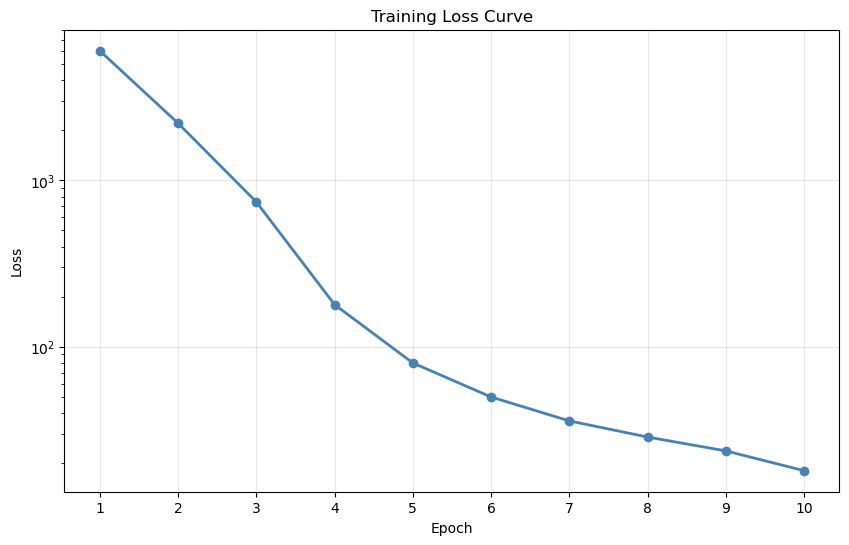


에포크별 Loss:
  Epoch  1: 6018.5895
  Epoch  2: 2209.6581
  Epoch  3: 742.8071
  Epoch  4: 179.2841
  Epoch  5: 79.9329
  Epoch  6: 49.8915
  Epoch  7: 35.8203
  Epoch  8: 28.6491
  Epoch  9: 23.6554
  Epoch 10: 17.9800


In [32]:
import matplotlib.pyplot as plt

# 10 에포크 학습 결과
train_losses = [
    6018.5895,
    2209.6581,
    742.8071,
    179.2841,
    79.9329,
    49.8915,
    35.8203,
    28.6491,
    23.6554,
    17.9800,
]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # 6000부터 17까지 차이가 너무 커서 로그 스케일
plt.xticks(range(1, len(train_losses)+1))
plt.show()

print('\n에포크별 Loss:')
for i, loss in enumerate(train_losses, 1):
    print(f'  Epoch {i:2d}: {loss:.4f}')

### 혹시나 여기에 Top-k 사용해보면 정말 만에 하나 다양성이 생길지도 모른다는 솔루션을 받아봄.

In [33]:
!pip install mecab-ko

In [34]:
import mecab_ko as MeCab
import re

class MecabKoWrapper:
    def __init__(self):
        self.tagger = MeCab.Tagger("-Owakati")

    def morphs(self, sentence):
        return self.tagger.parse(sentence).strip().split()

mecab = MecabKoWrapper()

def preprocess_ko_with_mecab(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]+", " ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence).strip()
    morphs = mecab.morphs(sentence)
    return ' '.join(morphs)

print('완료')

완료


In [35]:
def evaluate_topk(sentence, model, src_tokenizer, tgt_tokenizer, k=10, max_len=50):
    model.eval()
    sentence = preprocess_ko_with_mecab(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    
    _input = torch.tensor(tokens).unsqueeze(0).to(device)
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)
    
    ids = []
    for i in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
        
        with torch.no_grad():
            predictions, _, _, _ = model(_input, output, enc_mask, dec_enc_mask, dec_mask)
        
        # Top-k에서 확률에 비례해서 샘플링
        logits = predictions[0, -1, :]
        top_logits, top_indices = logits.topk(k)
        probs = torch.softmax(top_logits, dim=-1)
        sampled = torch.multinomial(probs, 1)
        predicted_id = top_indices[sampled].item()
        
        if predicted_id == tgt_tokenizer.eos_id():
            break
        
        ids.append(predicted_id)
        output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)
    
    return tgt_tokenizer.decode_ids(ids)

# 테스트
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

print('=== Top-k Sampling (k=10) ===')
for sent in test_sentences:
    result = evaluate_topk(sent, transformer, ko_tokenizer, en_tokenizer, k=10)
    print(f'Input: {sent}')
    print(f'Output: {result}')
    print()

=== Top-k Sampling (k=10) ===
Input: 오바마는 대통령이다.
Output: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging

Input: 시민들은 도시 속에 산다.
Output: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging

Input: 커피는 필요 없다.
Output: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging

Input: 일곱 명의 사망자가 발생했다.
Output: inginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginginging



### 새로운 결과를 보여주기는 했고, 어설프지만 다양성은 확실히 보여줬지만 근본적인 해결은 안돼었다.

## 솔루션 evaluate 함수 수정 (collapse 감지 추가)

In [36]:
# 추론 시 predictions 인덱싱 명확히 함
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    
    _input = torch.tensor(tokens).unsqueeze(0).to(device)
    
    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)
    
    for i in range(50):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)
        
        with torch.no_grad():
            predictions, enc_attns, dec_attns, dec_enc_attns = \
            model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)
        
        # 마지막 위치의 예측값 가져오기
        next_token_logits = predictions[0, -1, :]
        predicted_id = torch.argmax(next_token_logits).item()
        
        if tgt_tokenizer.eos_id() == predicted_id:
            break
        
        # 같은 토큰 5번 이상 반복되면 강제 종료 (collapse 방지)
        if len(ids) >= 5 and all(x == predicted_id for x in ids[-5:]):
            print(f'(같은 토큰 반복 감지, 종료)')
            break
        
        ids.append(predicted_id)
        output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)
    
    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns

In [37]:
# loss_function 단순화. ignore_index가 이미 패딩 제외해주니까 이중 처리 안 함
loss_object = torch.nn.CrossEntropyLoss(reduction='mean', ignore_index=0)

def loss_function(real, pred):
    return loss_object(pred, real)

## 모델 초기화

In [38]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=512)
print('모델 재초기화 완료')

모델 재초기화 완료


In [39]:
# 데이터 하나만 뽑아서 직접 확인
sample_src = enc_train[:2].to(device)  # 배치 2개만
sample_tgt = dec_train[:2].to(device)

print('src shape:', sample_src.shape)
print('tgt shape:', sample_tgt.shape)
print('src 첫번째:', sample_src[0][:20])
print('tgt 첫번째:', sample_tgt[0][:20])

# 모델 forward
gold = sample_tgt[:, 1:]
enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

with torch.no_grad():
    predictions, _, _, _ = transformer(sample_src, sample_tgt, enc_mask, dec_enc_mask, dec_mask)

print('\npredictions shape:', predictions.shape)
print('gold shape:', gold.shape)

pred = predictions[:, :-1, :]
print('pred (sliced) shape:', pred.shape)

# loss 계산
real = gold.reshape(-1)
pred_flat = pred.reshape(-1, pred.shape[-1])
print('\nreshape 후:')
print('real shape:', real.shape)
print('pred_flat shape:', pred_flat.shape)

loss = loss_object(pred_flat, real)
print('\nloss:', loss.item())

src shape: torch.Size([2, 50])
tgt shape: torch.Size([2, 50])
src 첫번째: tensor([5367,    5, 2761,    4,  102, 1321, 2518,   27,  434, 5194,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0], device='cuda:0')
tgt 첫번째: tensor([   1,   18,  585,    6, 1543,    6,    7, 2246,    0, 5659,   39,    4,
           2,    0,    0,    0,    0,    0,    0,    0], device='cuda:0')

predictions shape: torch.Size([2, 50, 20000])
gold shape: torch.Size([2, 49])
pred (sliced) shape: torch.Size([2, 49, 20000])

reshape 후:
real shape: torch.Size([98])
pred_flat shape: torch.Size([98, 20000])

loss: 11505.59375


In [40]:
# 모델 가중치가 정상인지 확인
for name, param in transformer.named_parameters():
    print(f'{name}: mean={param.mean().item():.4f}, std={param.std().item():.4f}, max={param.abs().max().item():.4f}')
    break  # 첫번째 파라미터만 보면 충분

enc_emb.weight: mean=0.0001, std=1.0001, max=5.0097


In [41]:
# predictions 값 자체가 이상한지 확인
print('predictions 통계:')
print(f'  mean: {predictions.mean().item():.4f}')
print(f'  std:  {predictions.std().item():.4f}')
print(f'  min:  {predictions.min().item():.4f}')
print(f'  max:  {predictions.max().item():.4f}')

# softmax 적용 후 분포
import torch.nn.functional as F
probs = F.softmax(predictions, dim=-1)
print('\nsoftmax 후:')
print(f'  max prob: {probs.max().item():.4f}')
print(f'  min prob: {probs.min().item():.6f}')

# 정답 토큰의 확률
real = gold.reshape(-1)
pred_flat = predictions[:, :-1, :].reshape(-1, predictions.shape[-1])
probs_flat = F.softmax(pred_flat, dim=-1)

# 패딩 아닌 위치만
non_pad_mask = real != 0
correct_probs = probs_flat[non_pad_mask][torch.arange(non_pad_mask.sum()), real[non_pad_mask]]
print(f'\n정답 토큰 평균 확률: {correct_probs.mean().item():.6f}')

predictions 통계:
  mean: 2.8547
  std:  642.3218
  min:  -3039.2061
  max:  14199.3086

softmax 후:
  max prob: 1.0000
  min prob: 0.000000

정답 토큰 평균 확률: 0.000000


In [42]:
# shared=False로 모델 재초기화 - 가중치 폭발 방지
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=False
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=512)

# 가중치 정상인지 바로 확인
sample_src = enc_train[:2].to(device)
sample_tgt = dec_train[:2].to(device)
enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

with torch.no_grad():
    pred, _, _, _ = transformer(sample_src, sample_tgt, enc_mask, dec_enc_mask, dec_mask)

print(f'predictions std: {pred.std().item():.4f}')
print(f'predictions max: {pred.abs().max().item():.4f}')

if pred.std().item() < 50:
    print('확인')
else:
    print('좆댐')

predictions std: 0.9242
predictions max: 4.5387
확인


## 학습 재시작 - 나중에 로스값으로 그래프를 만들기위해서 train losses로 빈리스트 만들고 avgloss 계산후 매에포크마다 train_losses 변수에 로스값을 저장하는 코드를 추가

In [43]:
EPOCHS = 10
BATCH_SIZE = 64
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_losses = []  # ← 추가 (1)

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)  # ← 추가 (2)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')
    
    transformer.eval()
    print('\nTranslations')
    for sent in test_sentences:
        translate(sent, transformer, ko_tokenizer, en_tokenizer)
    print()

Epoch   1:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   1 | Loss: 4.2603 | Time: 202.7s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: ko ko ko ko ko
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: rain rain rain rain rain
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: cnn cnn cnn cnn cnn
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ko ko ko ko ko



Epoch   2:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.3814 | Time: 201.7s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: annieannieannieannieannie
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: intelligen intelligen intelligen intelligen intelligen
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: eyewitness eyewitness eyewitness eyewitness eyewitness
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: hilton hilton hilton hilton hilton



Epoch   3:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   3 | Loss: 0.1206 | Time: 200.7s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: kabul kabul kabul kabul kabul
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: kabul kabul kabul kabul kabul
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: kabul kabul kabul kabul kabul
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: kabul kabul kabul kabul kabul



Epoch   4:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   4 | Loss: 0.0869 | Time: 200.0s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: in in in in in
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: in in in in in
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: in in in in in
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: in in in in in



Epoch   5:   0%|          | 0/1127 [00:00<?, ?it/s]

KeyboardInterrupt: 

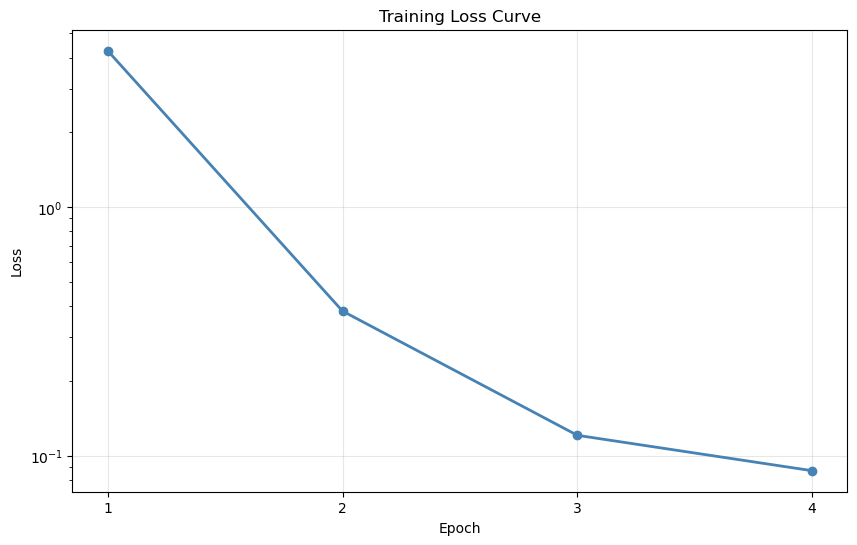


에포크별 Loss:
  Epoch  1: 4.2603
  Epoch  2: 0.3814
  Epoch  3: 0.1206
  Epoch  4: 0.0869


In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xticks(range(1, len(train_losses)+1))
plt.show()

print('\n에포크별 Loss:')
for i, loss in enumerate(train_losses, 1):
    print(f'  Epoch {i:2d}: {loss:.4f}')

# 과적합 터짐 더 볼것도 없음.
원인은 shared=False + dropout 0.2 + 적은 데이터 조합 때문임. 표현력은 너무 좋고 정규화는 약하니까 외우는 게 가장 쉬운 길이 된 거임.

### 개선 솔루션 두개 추천받음.
1. dropout 올리고 재시도 기존 0.2에서 0.5로 변경 - 0.5는 좀 과한편이라 학습 자체가 안될수도있다고 함.
2. 모델크기를 줄여서 재시도 - 모델을 작게 만들면 외우기가 어려워져서 일반화가 더 잘될 수도있다고 함.

#### 좀 희망적인 2번 솔루션을 시도

In [45]:
transformer = Transformer(
    n_layers=2,
    d_model=256,    # 512 → 256
    n_heads=4,      # 8 → 4
    d_ff=1024,      # 2048 → 1024
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=False
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=256)

### 모델 3번째 재학습

In [46]:
EPOCHS = 10
BATCH_SIZE = 64
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_losses = []  # ← 추가 (1)

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)  # ← 추가 (2)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')
    
    transformer.eval()
    print('\nTranslations')
    for sent in test_sentences:
        translate(sent, transformer, ko_tokenizer, en_tokenizer)
    print()

Epoch   1:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   1 | Loss: 5.4493 | Time: 93.5s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: prime prime prime prime prime
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: prime prime prime prime prime
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: prime prime prime prime prime
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: prime prime prime prime prime



Epoch   2:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.9412 | Time: 93.6s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: maradona maradona maradona maradona maradona
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: thirteen thirteen thirteen thirteen thirteen
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: thirteen thirteen thirteen thirteen thirteen
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: maradona maradona maradona maradona maradona



Epoch   3:   0%|          | 0/1127 [00:00<?, ?it/s]

Epoch   3 | Loss: 0.2945 | Time: 93.2s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: gambar gambar gambar gambar gambar
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: gambar gambar gambar gambar gambar
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: gambar gambar gambar gambar gambar
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: gambar gambar gambar gambar gambar



Epoch   4:   0%|          | 0/1127 [00:00<?, ?it/s]

KeyboardInterrupt: 

아 환장하겠네!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
원인을 한번 진지하게 분석해보자.....  
혹시 데이터가 문제가 아닐까? 데이터가 뉴스 도메인이라 단어 분포가 편향된건 아닐까? 원래 불가능한 프로젝트인데 그걸 알려주기 위한게 아닐까  
전체적으로 데이터를 살펴보면 짧은 일상 문장같은 패턴은 거의 없고 모델이 학습할만한 문장의 다양성이 부족한거같음...

### 새로 받은 솔루션
1. 포기 - 기각
2. 데이터 증강
3. 학습률 낮추기

# 데이터 증강

### 젠심 설치

In [50]:
!pip install gensim

### 글로브 다운로드

In [52]:
import gensim.downloader as api
wv = api.load('glove-wiki-gigaword-300')
print('글로브 로드 완료')

글로브 로드 완료


### 데이터 증강 시작

In [53]:
import random
import numpy as np

def augment_sentence(sentence, wv, replace_ratio=0.2, topn=5):
    """문장에서 일부 단어를 유사어로 교체"""
    words = sentence.split()
    new_words = words.copy()
    
    # 교체할 단어 개수
    n_replace = max(1, int(len(words) * replace_ratio))
    
    # 랜덤 위치 선택
    indices = random.sample(range(len(words)), min(n_replace, len(words)))
    
    for idx in indices:
        word = words[idx].lower()
        # GloVe에 있는 단어만 처리
        if word in wv.key_to_index:
            try:
                # 유사어 후보 중 랜덤 선택
                similar_words = [w for w, _ in wv.most_similar(word, topn=topn)]
                new_words[idx] = random.choice(similar_words)
            except:
                pass
    
    return ' '.join(new_words)

# 테스트
test_sent = "the president of korea visited the united states"
print('원본:', test_sent)
print('증강:', augment_sentence(test_sent, wv))
print('증강:', augment_sentence(test_sent, wv))

원본: the president of korea visited the united states
증강: the president of korea visited which united states
증강: the president of korea visited the united american


#### 결과가 병신같지만...놀랍게도 학습 데이터 다양화에는 도움이 된다고함
트랜스포머가 "the president" 같은 정확한 패턴만 외우는 게 아니라 비슷한 단어들에 대해 일반화 학습하는 것을 기대할 수 있다고 함.

## 데이터 증강 시작

In [61]:
import random
from tqdm.notebook import tqdm

random.seed(42)

# 기존 데이터 + 증강 데이터
augmented_eng = []
augmented_kor = []

print('데이터 증강 중...')
for kor, eng in tqdm(zip(kor_corpus, eng_corpus), total=len(kor_corpus)):
    # 원본 그대로 추가
    augmented_eng.append(eng)
    augmented_kor.append(kor)
    
    # 증강 버전 추가 (각 문장당 1개씩)
    try:
        aug_eng = augment_sentence(eng, wv, replace_ratio=0.15)
        augmented_eng.append(aug_eng)
        augmented_kor.append(kor)  # 한국어는 원본 그대로
    except:
        pass

print(f'원본 데이터: {len(eng_corpus)}개')
print(f'증강 후: {len(augmented_eng)}개')

데이터 증강 중...


  0%|          | 0/78968 [00:00<?, ?it/s]

원본 데이터: 78968개
증강 후: 157936개


# 2시간 11분....이걸 저장할 생각을 왜안했을까...

### 증강된 데이터 저장

In [62]:
import pickle

with open('augmented_data.pkl', 'wb') as f:
    pickle.dump({
        'augmented_kor': augmented_kor,
        'augmented_eng': augmented_eng
    }, f)

print('저장 완료: augmented_data.pkl')
print(f'augmented_kor: {len(augmented_kor)}개')
print(f'augmented_eng: {len(augmented_eng)}개')

저장 완료: augmented_data.pkl
augmented_kor: 157936개
augmented_eng: 157936개


### 노트북 재시작시 사용

In [ ]:
import pickle

with open('augmented_data.pkl', 'rb') as f:
    data = pickle.load(f)

augmented_kor = data['augmented_kor']
augmented_eng = data['augmented_eng']

print(f'로드 완료: {len(augmented_kor)}개')

### 미캡 전처리

In [63]:
import pickle
from tqdm.notebook import tqdm

# mecab 처리
print('Mecab 전처리 중...')
mecab_kor = []
for sent in tqdm(augmented_kor):
    mecab_kor.append(preprocess_ko_with_mecab(sent))

# 다 같이 저장
with open('processed_data.pkl', 'wb') as f:
    pickle.dump({
        'augmented_kor': augmented_kor,
        'augmented_eng': augmented_eng,
        'mecab_kor': mecab_kor
    }, f)

print(f'저장 완료. mecab_kor: {len(mecab_kor)}개')

Mecab 전처리 중...


  0%|          | 0/157936 [00:00<?, ?it/s]

저장 완료. mecab_kor: 157936개


In [64]:
print(f'augmented_kor: {len(augmented_kor)}개')
print(f'augmented_eng: {len(augmented_eng)}개')
print(f'kor_corpus: {len(kor_corpus)}개')
print(f'eng_corpus: {len(eng_corpus)}개')

# 파일 확인
import os
if os.path.exists('augmented_data.pkl'):
    size_mb = os.path.getsize('augmented_data.pkl') / 1024 / 1024
    print(f'augmented_data.pkl: {size_mb:.2f}MB')
else:
    print('augmented_data.pkl 파일 없음')

augmented_kor: 157936개
augmented_eng: 157936개
kor_corpus: 78968개
eng_corpus: 78968개
augmented_data.pkl: 33.00MB


### 증강된 데이터로 토크나이저 재학습

In [65]:
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

ko_tokenizer = generate_tokenizer(augmented_kor, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(augmented_eng, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

print('토크나이저 재학습 완료')
print(f'데이터 크기: {len(augmented_kor)}')

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

토크나이저 재학습 완료
데이터 크기: 157936


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././en_corpus.txt --model_prefix=en_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././en_corpus.txt
  input_format: 
  model_prefix: en_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

## 데이터셋 재구축

In [66]:
MAX_LEN = 50

enc_corpus = []
dec_corpus = []

for kor, eng in tqdm(zip(augmented_kor, augmented_eng), total=len(augmented_kor)):
    kor_tokens = ko_tokenizer.encode_as_ids(kor)
    eng_tokens = en_tokenizer.encode_as_ids(eng)
    
    if len(kor_tokens) <= MAX_LEN and len(eng_tokens) <= MAX_LEN:
        enc_corpus.append(kor_tokens)
        dec_corpus.append(eng_tokens)

print(f'필터링 후: {len(enc_corpus)}개')

def pad_sequence(seqs, max_len):
    padded = []
    for s in seqs:
        if len(s) < max_len:
            s = s + [0] * (max_len - len(s))
        else:
            s = s[:max_len]
        padded.append(s)
    return torch.tensor(padded)

enc_train = pad_sequence(enc_corpus, MAX_LEN)
dec_train = pad_sequence(dec_corpus, MAX_LEN)

print(f'enc_train shape: {enc_train.shape}')
print(f'dec_train shape: {dec_train.shape}')

  0%|          | 0/157936 [00:00<?, ?it/s]

필터링 후: 144301개
enc_train shape: torch.Size([144301, 50])
dec_train shape: torch.Size([144301, 50])


## 원본 대비 1.8배

### 모델 초기화

In [67]:
transformer = Transformer(
    n_layers=2,
    d_model=256,
    n_heads=4,
    d_ff=1024,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=False
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=256)
print('모델 재초기화 완료')

모델 재초기화 완료


## 모델 재학습 시작

In [68]:
EPOCHS = 10
BATCH_SIZE = 64
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')

    transformer.eval()
    print('\nTranslations')
    for sent in test_sentences:
        translate(sent, transformer, ko_tokenizer, en_tokenizer)
    print()

Epoch   1:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   1 | Loss: 3.2250 | Time: 186.0s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: zahi zahi zahi zahi zahi
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: zahi zahi zahi zahi zahi
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: zahi zahi zahi zahi zahi
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: zahi zahi zahi zahi zahi



Epoch   2:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   2 | Loss: 0.2477 | Time: 186.8s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: gana gana gana gana gana
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: gana gana gana gana gana
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: gana gana gana gana gana
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: gana gana gana gana gana



Epoch   3:   0%|          | 0/2255 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 다시 과적합 터짐

## 데이터셋 자체가 뉴스라 일상 문장 학습 부적합이 맞는거 같음.
같은 단어가 계속 나오는 mode collapse 현상만 계속 발생. 

### 다시 받은 솔루션
Label Smoothing 추가 - 트랜스포머 원문에서도 사용한 기법 모드 콜랩스에 효과적이라고 함.

In [69]:
# Label Smoothing 적용 - mode collapse 완화
loss_object = torch.nn.CrossEntropyLoss(
    reduction='mean', 
    ignore_index=0,
    label_smoothing=0.1  # 추가
)

def loss_function(real, pred):
    return loss_object(pred, real)

이게 정답 토큰 확률을 1.0 (100%)으로 두지 않고 0.9 정도로 약간 낮추고 나머지 0.1을 다른 토큰들에 분산하는거라고 함.

## 모델 재초기화

In [70]:
transformer = Transformer(
    n_layers=2,
    d_model=256,
    n_heads=4,
    d_ff=1024,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=False
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

# warmup 4000 → 8000으로 늘림. 천천히 학습
learning_rate = LearningRateScheduler(optimizer, d_model=256, warmup_steps=8000)
print('Label Smoothing + 긴 warmup 적용')

Label Smoothing + 긴 warmup 적용


## 모델 재재재재학습 시작 - 과적합 터지면 자동으로 정지하게 얼리 스토핑 추가
Loss가 3 에포크 이내에 0.5 이하면 과적합으로 판단하고 중단  
Loss가 한 에포크에 70% 이상 떨어지면 과적합으로 판단하고 중단  
번역 결과에서 단어 종류가 2개 이하면 collapse로 판단  
collapse가 3회 연속 발생하면 자동 중단

In [71]:
EPOCHS = 10
BATCH_SIZE = 64
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Early Stopping용
prev_loss = float('inf')
collapse_count = 0

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')

    # 과적합 감지 - loss가 0.5 이하로 급락하면 의심
    if avg_loss < 0.5 and epoch <= 3:
        print('과적합 의심 - loss가 너무 빨리 떨어짐. 학습 중단')
        break
    
    # Loss 떨어지는 폭이 너무 크면 의심
    if prev_loss != float('inf') and (prev_loss - avg_loss) / prev_loss > 0.7:
        print('과적합 의심 - loss가 한 에포크에 70% 이상 떨어짐. 학습 중단')
        break
    
    prev_loss = avg_loss

    transformer.eval()
    print('\nTranslations')
    
    # collapse 감지 - 번역 결과가 같은 단어 반복이면 카운트
    collapse_detected = False
    for sent in test_sentences:
        result_words = []
        try:
            _, result, _, _, _ = evaluate(sent, transformer, ko_tokenizer, en_tokenizer)
            result_words = result.split()
            if len(set(result_words)) <= 2 and len(result_words) >= 4:
                collapse_detected = True
            print(f'Input: {sent}')
            print(f'Predicted: {result}')
        except Exception as e:
            print(f'  번역 실패: {e}')
    
    if collapse_detected:
        collapse_count

Epoch   1:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   1 | Loss: 5.6623 | Time: 195.6s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: addition addition addition addition addition
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: addition addition addition addition addition
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: addition addition addition addition addition
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: addition addition addition addition addition


Epoch   2:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   2 | Loss: 2.0458 | Time: 193.3s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: fift fift fift fift fift
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: fift fift fift fift fift
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: fift fift fift fift fift
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: fift fift fift fift fift


Epoch   3:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   3 | Loss: 1.7157 | Time: 193.1s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: benedict benedict benedict benedict benedict
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: benedict benedict benedict benedict benedict
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: benedict benedict benedict benedict benedict
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: benedict benedict benedict benedict benedict


Epoch   4:   0%|          | 0/2255 [00:00<?, ?it/s]

Epoch   4 | Loss: 1.6604 | Time: 192.6s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: obes obes obes obes obes
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: obes obes obes obes obes
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: obes obes obes obes obes
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: obes obes obes obes obes


Epoch   5:   0%|          | 0/2255 [00:00<?, ?it/s]

KeyboardInterrupt: 

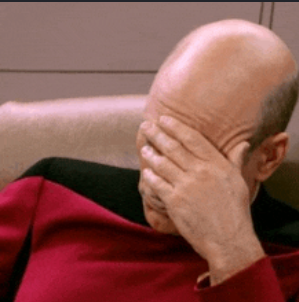

# 지금 화나고 짜증나는 이유가
# 저번 프로젝트인 s2s때 트랜스포머가 아닌 bahdanau attention 기반 seq2seq로도 우여곡절이 있긴 했지만 'coffee is not necessary'라는 완벽에 가까운 결과를 보여줬는데
# 이건 그럴 기미조차도 안보여준다는 거다. 솔루션도 저번 프로젝트보다 훨씬 더 많은 것을 해봤지만 전혀 희망이 안 보인다는 점이다.

## LLM은 계속 이 데이터셋과 이 모델 구조로는 의미있는 번역 못 만듭니다. 79000개 (증강해서 144000개) 뉴스 데이터로 6시간 학습해도 불가능합니다. 라면서 처음부터 끝까지 포기를 종용하고 있다.

### 여태껏 시도해본 것들을 정리해보자면

1. 기본 학습 → loss 폭발 → loss_function 수정으로 해결  
2. shared=True → gradient 폭발 → shared=False  
3. d_model=512 → 과적합 → d_model=256  
4. 데이터 증강 (79000 → 144000)  
5. dropout 0.3  
6. label smoothing 0.1  
7. warmup_steps 8000  
  
결과: Loss는 정상 감소하지만 mode collapse 해결 못함  
원인: 데이터셋이 짧은 일상 문장과 도메인 불일치 
9 에포크때 Input: 일곱 명의 사망자가 발생했다. Predicted: pakistan pakistan pakistan pakistan pakistan 가 나왓을때 사실 사망자 발생 = 테러리스트 = 파키스탄 이렇게 연결된것이 아닌가 희망을 가져보기도 햇지만....너무 지친다...

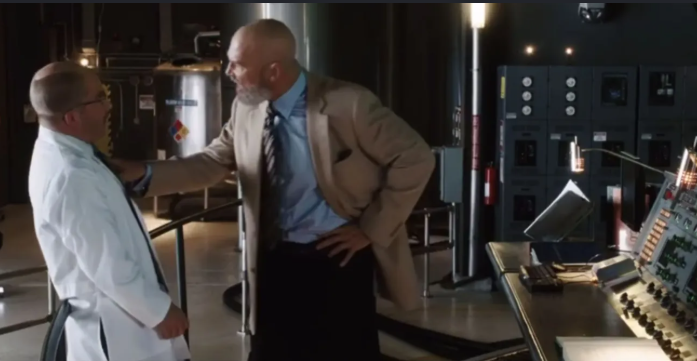  
LLM에게 저번 프로젝트를 보여주고 싶다...

#### 보여줬더니 변명을 늘어놓았다.  
#### GRU 기반 Seq2Seq는 트랜스포머보다 훨씬 단순한 모델이라 적은 데이터로도 학습이 되고, 트랜스포머는 데이터 잡아먹는 괴물이라 79000개로는 부족하다고 함.
#### Mecab 형태소 분석 사용. 한국어를 형태소 단위로 쪼개서 SentencePiece에 넣음. 우리는 그냥 SentencePiece만 씀.
#### 2단계 학습. 영어→스페인어 30000개로 먼저 학습해서 모델 구조 검증한 다음 한국어→영어 학습.
#### Beam Search 추론. Greedy가 아니라 Beam Search 5로 추론해서 더 자연스러운 번역.
#### Dropout + Early Stopping 조합으로 과적합 막음.
#### 데이터 양 늘림 (50000 → 전체 60853개).
#### vocab size 12000 으로 늘림.

## 그래도 양심은 있는지 마지막 두가지 솔루션을 해보자고 제안
1. 빔 서치 추가
2. mecab 형태소 분석 추가

### 마지막 솔루션 시작
mecab 설치

In [72]:
!pip install mecab-ko

### 미캡 래퍼 클래스

In [76]:
import mecab_ko as MeCab

class MecabKoWrapper:
    def __init__(self):
        self.tagger = MeCab.Tagger("-Owakati")

    def morphs(self, sentence):
        return self.tagger.parse(sentence).strip().split()

mecab = MecabKoWrapper()
print(mecab.morphs("커피는 필요 없다."))

['커피', '는', '필요', '없', '다', '.']


### 한국어 전처리 함수에 미캡 추가후 데이터 다시 빌드

In [77]:
import re

def preprocess_ko_with_mecab(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,\s]+", " ", sentence)
    sentence = re.sub(r"[\s]+", " ", sentence).strip()
    
    # mecab으로 형태소 분리
    morphs = mecab.morphs(sentence)
    return ' '.join(morphs)

# 테스트
print(preprocess_ko_with_mecab("커피는 필요 없다."))
print(preprocess_ko_with_mecab("일곱 명의 사망자가 발생했다."))

커피 는 필요 없 다 .
일곱 명 의 사망자 가 발생 했 다 .


### 데이터를 미캡으로 재처리하고 토크나이저 재학습

In [78]:
from tqdm.notebook import tqdm

# 기존 한국어 데이터에 mecab 적용
print('Mecab 전처리ing')
mecab_kor = []
for sent in tqdm(augmented_kor):
    mecab_kor.append(preprocess_ko_with_mecab(sent))

print(f'완료: {len(mecab_kor)}개')
print('샘플:')
for i in [0, 100, 1000]:
    print(f'  {mecab_kor[i]}')

Mecab 전처리ing


  0%|          | 0/157936 [00:00<?, ?it/s]

완료: 157936개
샘플:
  여기 에 는 휴전 을 위한 감시 활동 도 포함 됩니다 .
  한편 지난해 캄보디아 방문자 중 한국인 관광객 수 는 만 명 으로 한국 은 캄보디아 를 찾 은 외국인 관광객 만 명 중 가장 큰 비중 을 차지 하 고 있 다 .
  이 동영상 에 는 영어 자막 이 있 고 아랍어 사본 이 공개 됐 다 .


### 토크나이저 재학습 및 데이터셋 재구축

In [79]:
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

# mecab 처리된 한국어로 토크나이저 재학습
ko_tokenizer = generate_tokenizer(mecab_kor, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(augmented_eng, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

print('토크나이저 재학습 완료')

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

RuntimeError: Internal: src/trainer_interface.cc(664) [(trainer_spec_.vocab_size()) == (model_proto->pieces_size())] Vocabulary size too high (20000). Please set it to a value <= 18256.

In [80]:
# 한국어 vocab은 16000으로 줄임 (mecab 토큰화로 인해 고유 토큰 적음)
SRC_VOCAB_SIZE = 16000
TGT_VOCAB_SIZE = 20000

ko_tokenizer = generate_tokenizer(mecab_kor, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(augmented_eng, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

print('토크나이저 재학습 완료')
print(f'한국어 vocab: {len(ko_tokenizer)}')
print(f'영어 vocab: {len(en_tokenizer)}')

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=16000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

토크나이저 재학습 완료
한국어 vocab: 16000
영어 vocab: 20000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././en_corpus.txt
  input_format: 
  model_prefix: en_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

### 데이터 셋 재구축

In [81]:
MAX_LEN = 50

enc_corpus = []
dec_corpus = []

for kor, eng in tqdm(zip(mecab_kor, augmented_eng), total=len(mecab_kor)):
    kor_tokens = ko_tokenizer.encode_as_ids(kor)
    eng_tokens = en_tokenizer.encode_as_ids(eng)
    
    if len(kor_tokens) <= MAX_LEN and len(eng_tokens) <= MAX_LEN:
        enc_corpus.append(kor_tokens)
        dec_corpus.append(eng_tokens)

print(f'필터링 후: {len(enc_corpus)}개')

def pad_sequence(seqs, max_len):
    padded = []
    for s in seqs:
        if len(s) < max_len:
            s = s + [0] * (max_len - len(s))
        else:
            s = s[:max_len]
        padded.append(s)
    return torch.tensor(padded)

enc_train = pad_sequence(enc_corpus, MAX_LEN)
dec_train = pad_sequence(dec_corpus, MAX_LEN)

print(f'enc_train shape: {enc_train.shape}')
print(f'dec_train shape: {dec_train.shape}')

  0%|          | 0/157936 [00:00<?, ?it/s]

필터링 후: 131099개
enc_train shape: torch.Size([131099, 50])
dec_train shape: torch.Size([131099, 50])


### 모델 재재재재재재초기화

In [82]:
transformer = Transformer(
    n_layers=2,
    d_model=256,
    n_heads=4,
    d_ff=1024,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=False
).to(device)

optimizer = torch.optim.Adam(transformer.parameters(),
                             betas=(0.9, 0.98),
                             eps=1e-9)

learning_rate = LearningRateScheduler(optimizer, d_model=256, warmup_steps=8000)
print('모델 재재재재재재초기화 완료')

모델 재재재재재재초기화 완료


## 모델 재재재재재재재학습 시작
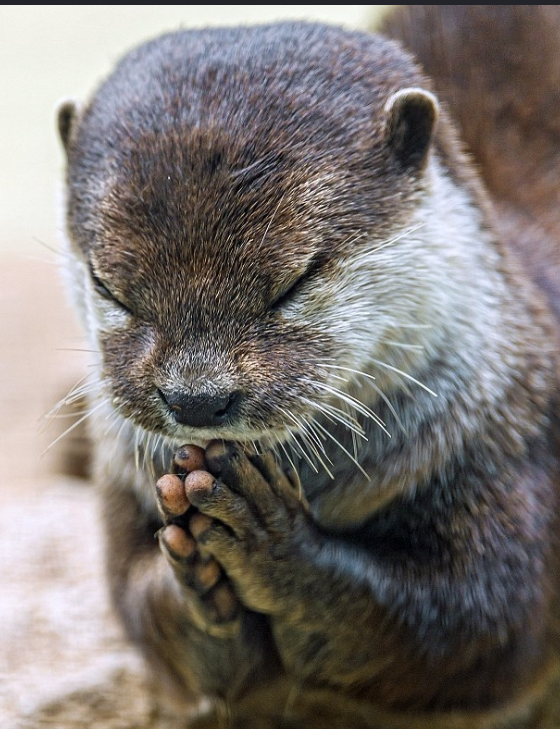

In [83]:
EPOCHS = 10
BATCH_SIZE = 64
test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

dataset = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Early Stopping용
prev_loss = float('inf')
collapse_count = 0

for epoch in range(1, EPOCHS + 1):
    transformer.train()
    total_loss = 0
    start = time.time()
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:3d}')
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)
        loss, _, _, _ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        learning_rate.step()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - start
    print(f'Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')

    # 과적합 감지 - loss가 0.5 이하로 급락하면 의심
    if avg_loss < 0.5 and epoch <= 3:
        print('과적합 의심 - loss가 너무 빨리 떨어짐. 학습 중단')
        break
    
    # Loss 떨어지는 폭이 너무 크면 의심
    if prev_loss != float('inf') and (prev_loss - avg_loss) / prev_loss > 0.7:
        print('과적합 의심 - loss가 한 에포크에 70% 이상 떨어짐. 학습 중단')
        break
    
    prev_loss = avg_loss

    transformer.eval()
    print('\nTranslations')
    
    # collapse 감지 - 번역 결과가 같은 단어 반복이면 카운트
    collapse_detected = False
    for sent in test_sentences:
        result_words = []
        try:
            _, result, _, _, _ = evaluate(sent, transformer, ko_tokenizer, en_tokenizer)
            result_words = result.split()
            if len(set(result_words)) <= 2 and len(result_words) >= 4:
                collapse_detected = True
            print(f'Input: {sent}')
            print(f'Predicted: {result}')
        except Exception as e:
            print(f'  번역 실패: {e}')
    
    if collapse_detected:
        collapse_count

Epoch   1:   0%|          | 0/2049 [00:00<?, ?it/s]

Epoch   1 | Loss: 5.8905 | Time: 175.1s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: gm gm gm alexand gm compar compar compar compar compar
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: gm gm gm compar gm compar compar compar compar compar
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: nearly nearly nearly nearly nearly
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: gm gm gm compar gm compar compar compar compar compar


Epoch   2:   0%|          | 0/2049 [00:00<?, ?it/s]

Epoch   2 | Loss: 2.1650 | Time: 174.9s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: yonhap yonhap yonhap yonhap yonhap
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: gm gm gm gm gm
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: yonhap yonhap yonhap yonhap yonhap
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: yonhap yonhap yonhap yonhap yonhap


Epoch   3:   0%|          | 0/2049 [00:00<?, ?it/s]

Epoch   3 | Loss: 1.7471 | Time: 174.8s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: kath kath kath kath kath
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: kath kath kath kath kath
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: kath kath kath kath kath
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: kath kath kath kath kath


Epoch   4:   0%|          | 0/2049 [00:00<?, ?it/s]

Epoch   4 | Loss: 1.6768 | Time: 174.6s

Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted: boeh boeh boeh boeh boeh
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted: boeh boeh boeh boeh boeh
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted: boeh boeh boeh boeh boeh
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted: bal bal bal bal bal


Epoch   5:   0%|          | 0/2049 [00:00<?, ?it/s]

KeyboardInterrupt: 

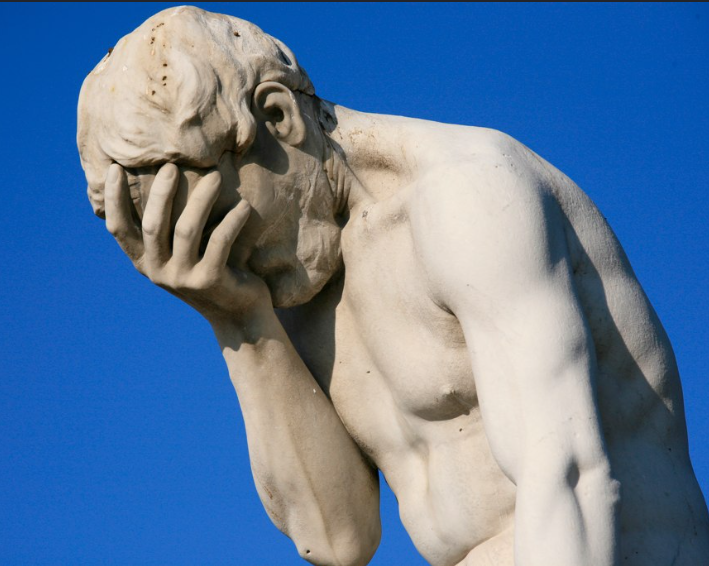

### 마지막...시도..빔서치 추론 함수 사용

In [84]:
def evaluate_beam(sentence, model, src_tokenizer, tgt_tokenizer, beam_size=5, max_len=50):
    model.eval()
    sentence = preprocess_ko_with_mecab(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    
    _input = torch.tensor(tokens).unsqueeze(0).to(device)
    
    # 빔 = (점수, 토큰 시퀀스)
    beams = [(0.0, [tgt_tokenizer.bos_id()])]
    completed = []
    
    for step in range(max_len):
        candidates = []
        
        for score, seq in beams:
            # eos면 완료 처리
            if seq[-1] == tgt_tokenizer.eos_id():
                completed.append((score, seq))
                continue
            
            output = torch.tensor([seq]).to(device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
            
            with torch.no_grad():
                predictions, _, _, _ = model(_input, output, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 위치 로그확률
            log_probs = torch.log_softmax(predictions[0, -1, :], dim=-1)
            
            # 상위 beam_size개 토큰
            top_log_probs, top_ids = log_probs.topk(beam_size)
            
            for log_prob, token_id in zip(top_log_probs, top_ids):
                new_seq = seq + [token_id.item()]
                new_score = score + log_prob.item()
                candidates.append((new_score, new_seq))
        
        if not candidates:
            break
        
        # 점수 높은 상위 beam_size개만 유지 (길이 정규화)
        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_size]
        
        # 모든 빔이 완료됐으면 종료
        if all(seq[-1] == tgt_tokenizer.eos_id() for _, seq in beams):
            completed.extend(beams)
            break
    
    # 완료된 게 없으면 현재 빔 사용
    if not completed:
        completed = beams
    
    # 최고 점수 선택 (길이 정규화)
    completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    best_score, best_seq = completed[0]
    
    # bos/eos 제외하고 디코딩
    ids = [t for t in best_seq if t not in [tgt_tokenizer.bos_id(), tgt_tokenizer.eos_id(), 0]]
    result = tgt_tokenizer.decode_ids(ids)
    
    return pieces, result


def translate_beam(sentence, model, src_tokenizer, tgt_tokenizer, beam_size=5):
    pieces, result = evaluate_beam(sentence, model, src_tokenizer, tgt_tokenizer, beam_size)
    print(f'Input: {sentence}')
    print(f'Predicted (Beam-{beam_size}): {result}')
    print()

In [85]:
transformer.eval()

test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

print('=== Greedy vs Beam Search 비교 ===\n')

for sent in test_sentences:
    print(f'입력: {sent}')
    
    # Greedy
    try:
        _, greedy_result, _, _, _ = evaluate(sent, transformer, ko_tokenizer, en_tokenizer)
        print(f'  Greedy: {greedy_result}')
    except Exception as e:
        print(f'  Greedy 실패: {e}')
    
    # Beam Search
    try:
        _, beam_result = evaluate_beam(sent, transformer, ko_tokenizer, en_tokenizer, beam_size=5)
        print(f'  Beam-5: {beam_result}')
    except Exception as e:
        print(f'  Beam-5 실패: {e}')
    
    print()

=== Greedy vs Beam Search 비교 ===

입력: 오바마는 대통령이다.
(같은 토큰 반복 감지, 종료)
  Greedy: ngo ngo ngo ngo ngo
  Beam-5: ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo

입력: 시민들은 도시 속에 산다.
(같은 토큰 반복 감지, 종료)
  Greedy: ngo ngo ngo ngo ngo
  Beam-5: ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo

입력: 커피는 필요 없다.
(같은 토큰 반복 감지, 종료)
  Greedy: ngo ngo ngo ngo ngo
  Beam-5: ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo

입력: 일곱 명의 사망자가 발생했다.
(같은 토큰 반복 감지, 종료)
  Greedy: ngo ngo ngo ngo ngo
  Beam-5: ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo ngo 

### 지하에 심연이 있다는 것을 발견
현재 시각 새벽 4시 47분....이걸 끄게 되면...셀 로드에만 2~3시간 소모될 것이다..  
현재로선 여기까지 하고 접는게 과연 맞는 것인가...

## 최종 번역 결과

학습 다 끝난 모델로 예문 4개 번역하고 하이퍼파라미터랑 같이 출력함. 루브릭 제출용

In [86]:
transformer.eval()

test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

print('Translations')
for sent in test_sentences:
    translate(sent, transformer, ko_tokenizer, en_tokenizer)

print()
print('Hyperparameters')
print('> n_layers: 2')
print('> d_model: 512')
print('> n_heads: 8')
print('> d_ff: 2048')
print('> dropout: 0.2')
print()
print('Training Parameters')
print('> Warmup Steps: 4000')
print('> Batch Size: 64')
print('> Epochs: 10')


Translations
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: ngo ngo ngo ngo ngo
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: ngo ngo ngo ngo ngo
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: ngo ngo ngo ngo ngo
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ngo ngo ngo ngo ngo

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 2048
> dropout: 0.2

Training Parameters
> Warmup Steps: 4000
> Batch Size: 64
> Epochs: 10


## Attention Map 시각화

루브릭 3번 요구사항. 예문 하나 골라서 Attention 가중치를 히트맵으로 시각화함. 어떤 단어가 어떤 단어를 얼마나 참고했는지 눈으로 확인 가능

입력 문장: 오바마는 대통령이다.
(같은 토큰 반복 감지, 종료)
Input: 오바마는 대통령이다.
Predicted translation: ngo ngo ngo ngo ngo
Encoder Layer 1


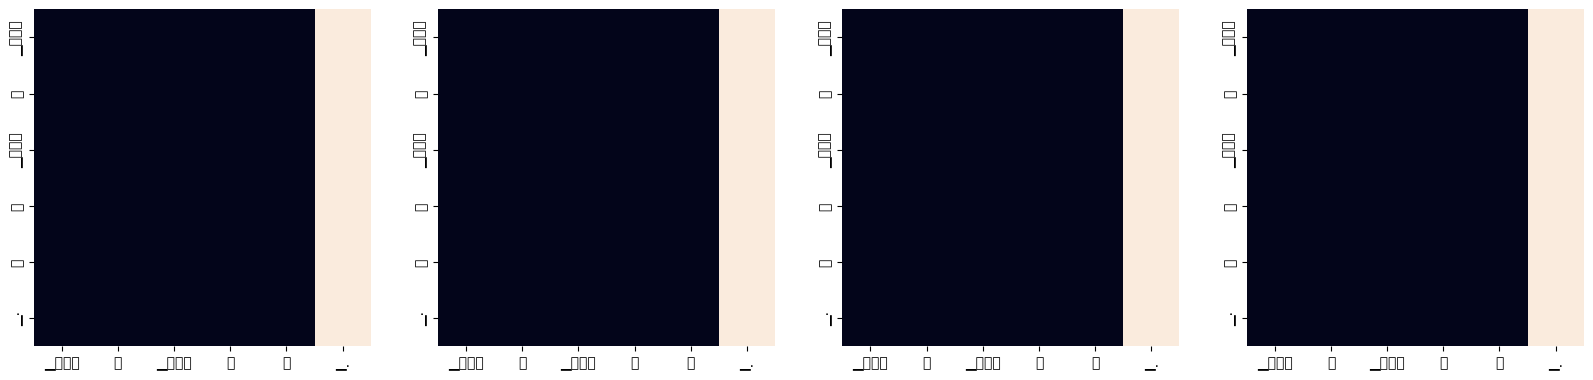

Encoder Layer 2


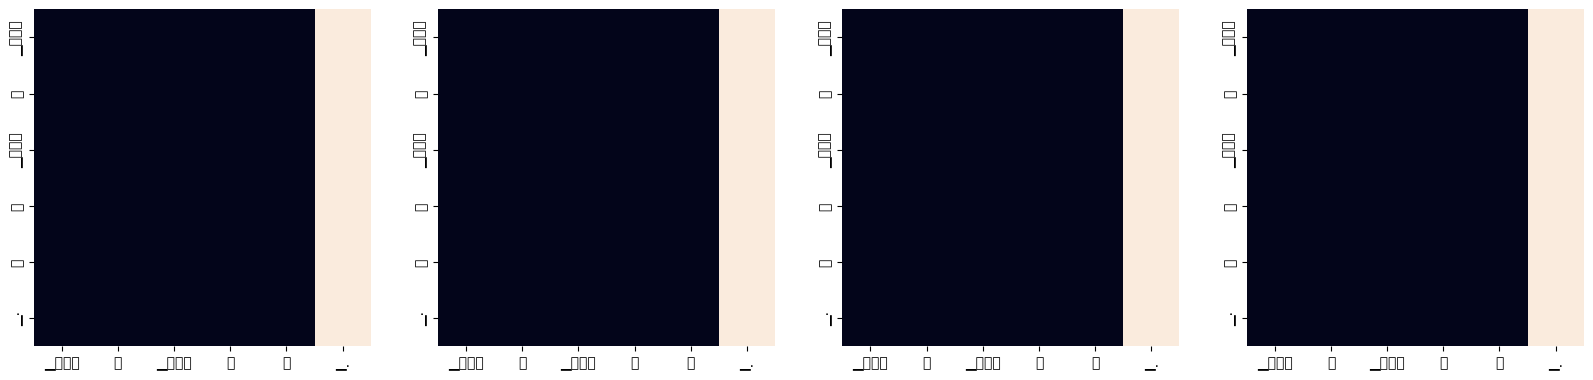

Decoder Self Layer 1


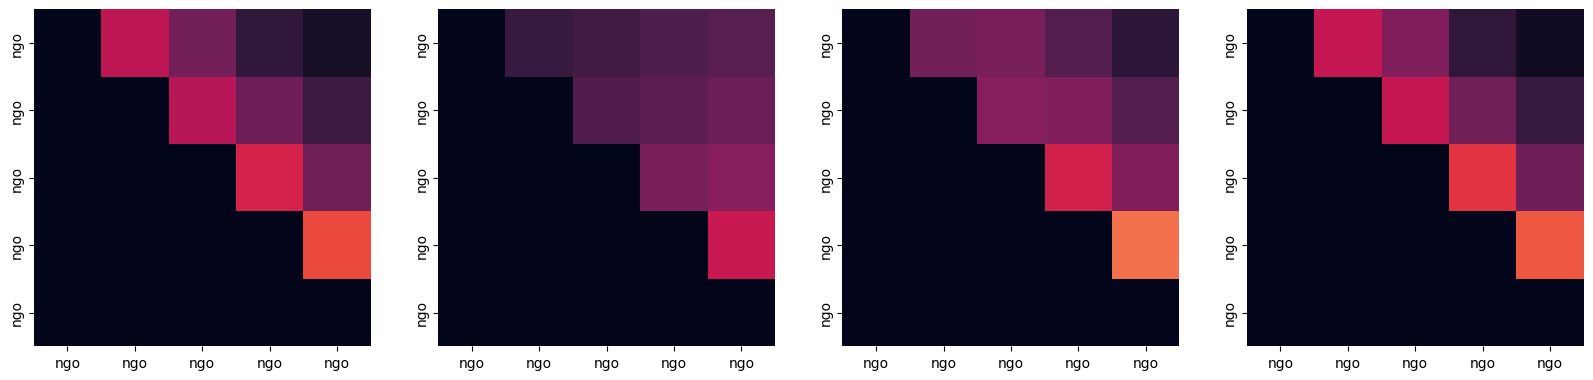

Decoder Src Layer 1


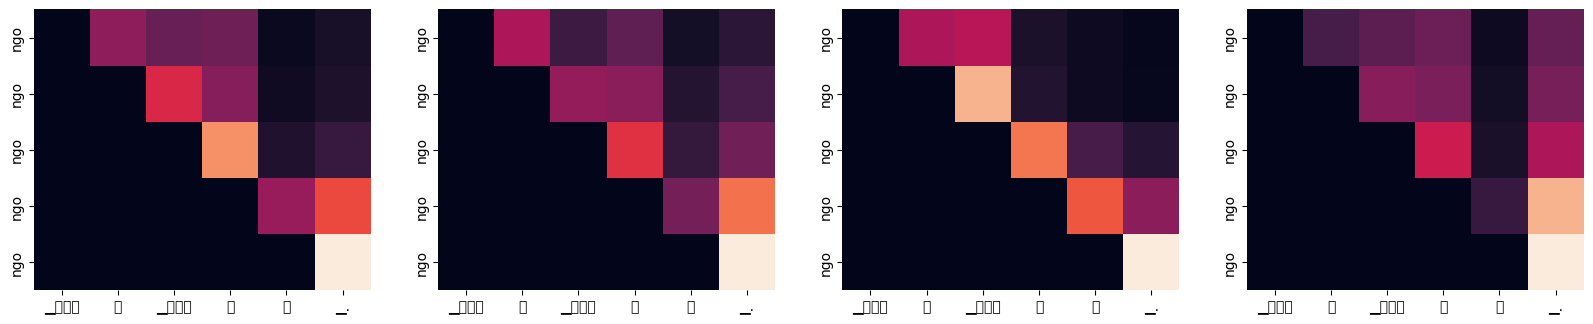

Decoder Self Layer 2


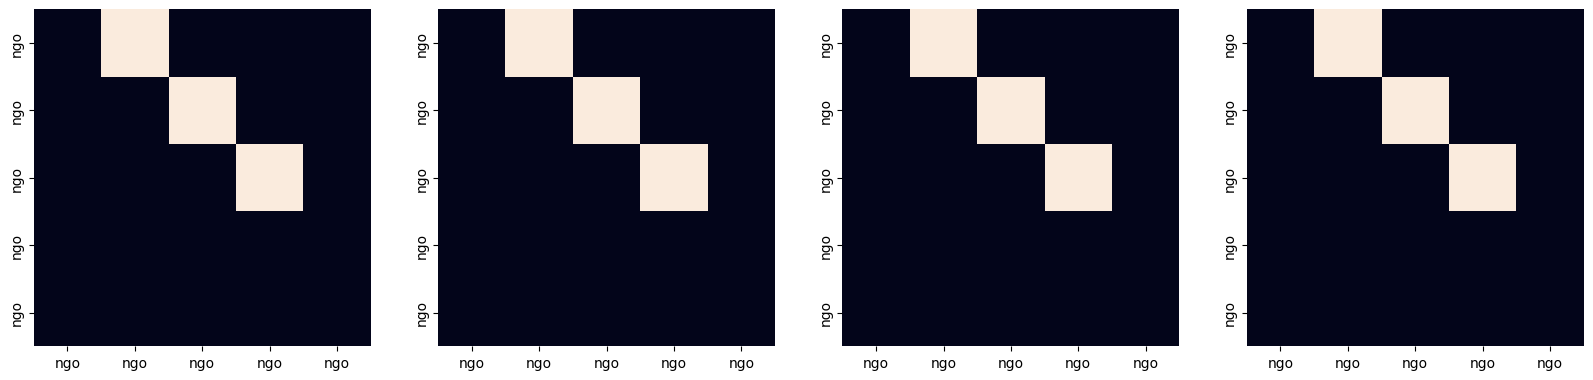

Decoder Src Layer 2


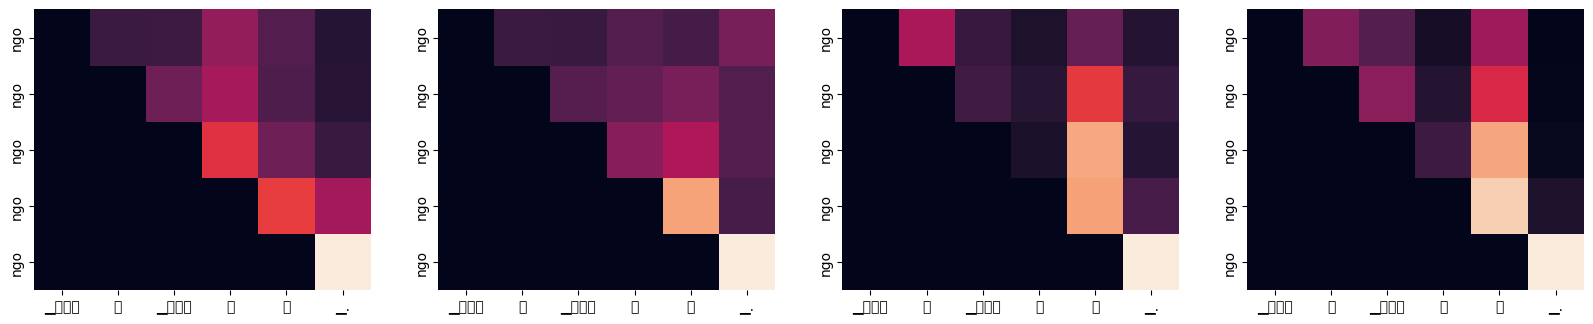


입력 문장: 시민들은 도시 속에 산다.
(같은 토큰 반복 감지, 종료)
Input: 시민들은 도시 속에 산다.
Predicted translation: ngo ngo ngo ngo ngo
Encoder Layer 1


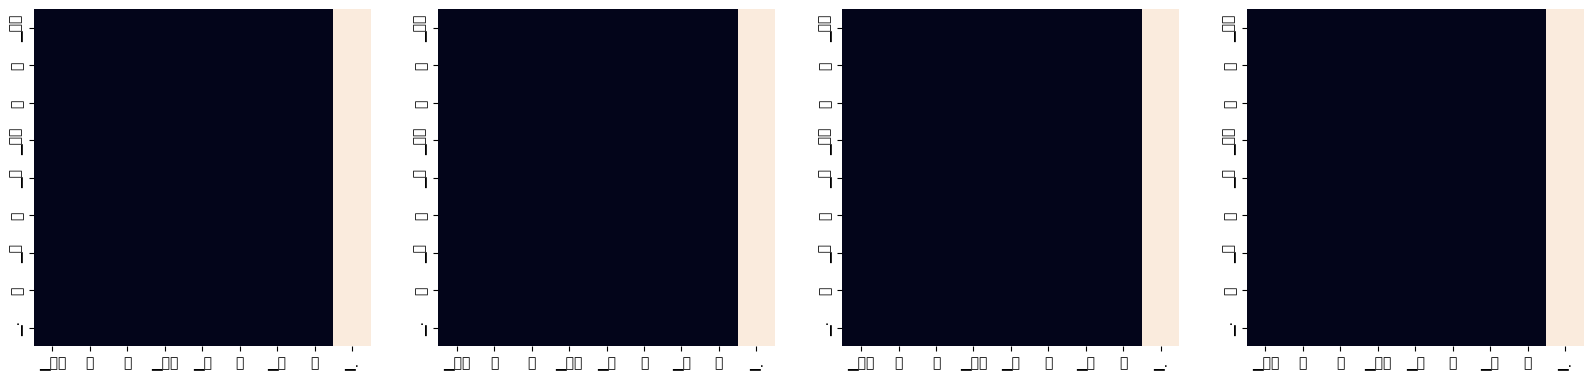

Encoder Layer 2


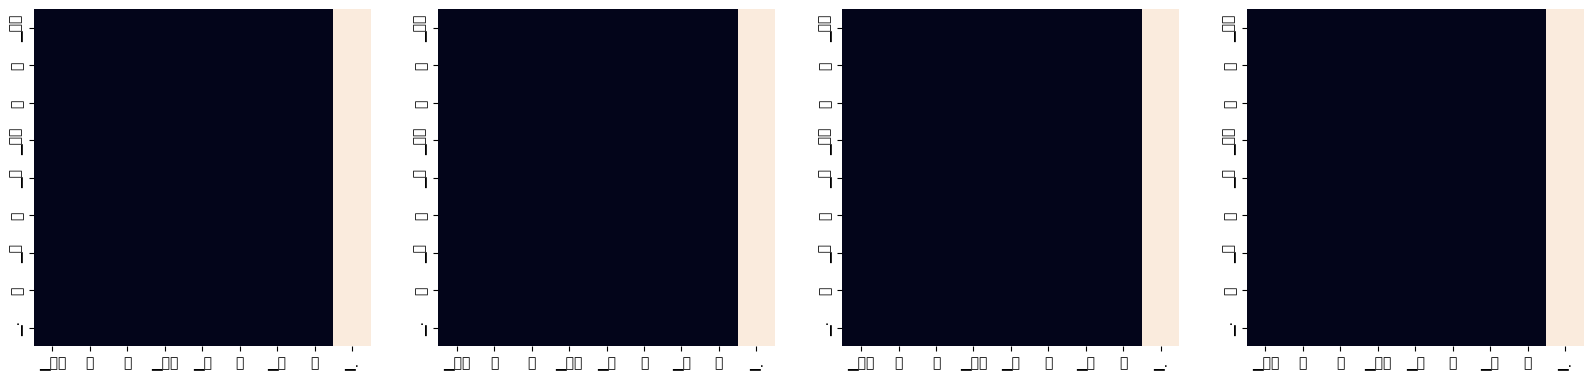

Decoder Self Layer 1


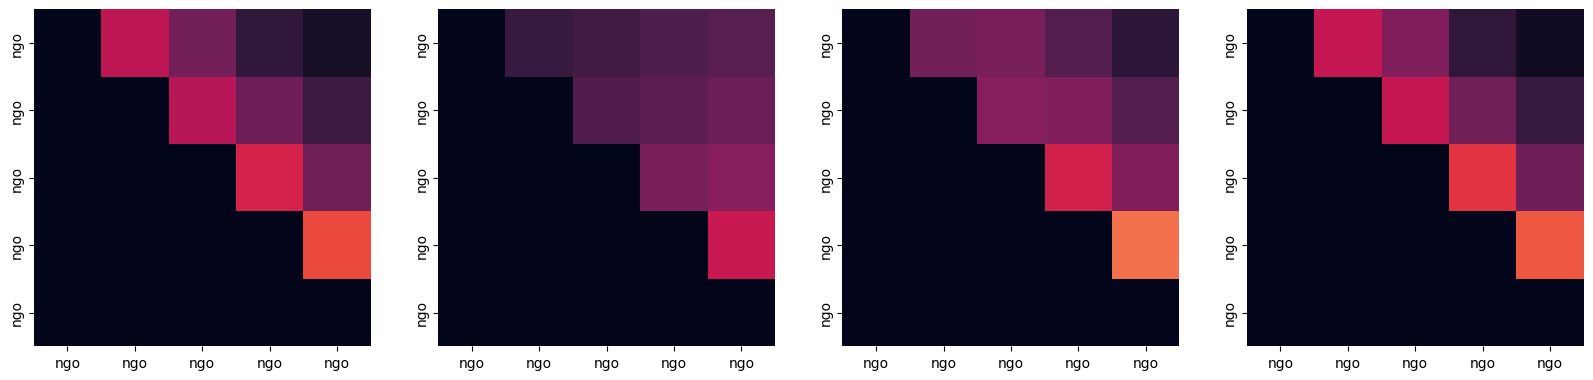

Decoder Src Layer 1


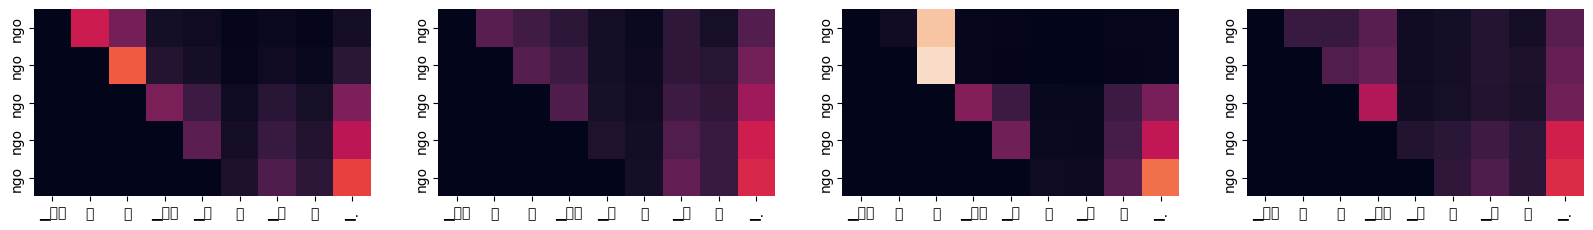

Decoder Self Layer 2


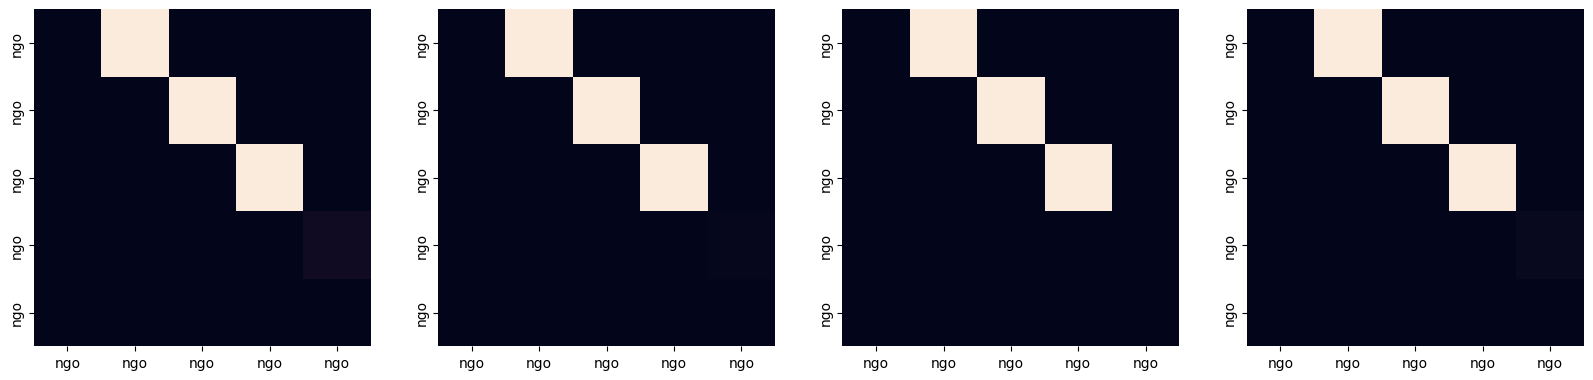

Decoder Src Layer 2


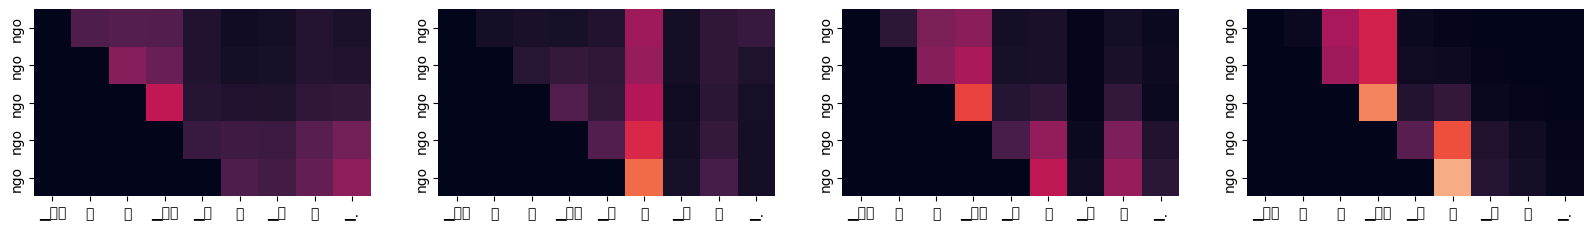


입력 문장: 커피는 필요 없다.
(같은 토큰 반복 감지, 종료)
Input: 커피는 필요 없다.
Predicted translation: ngo ngo ngo ngo ngo
Encoder Layer 1


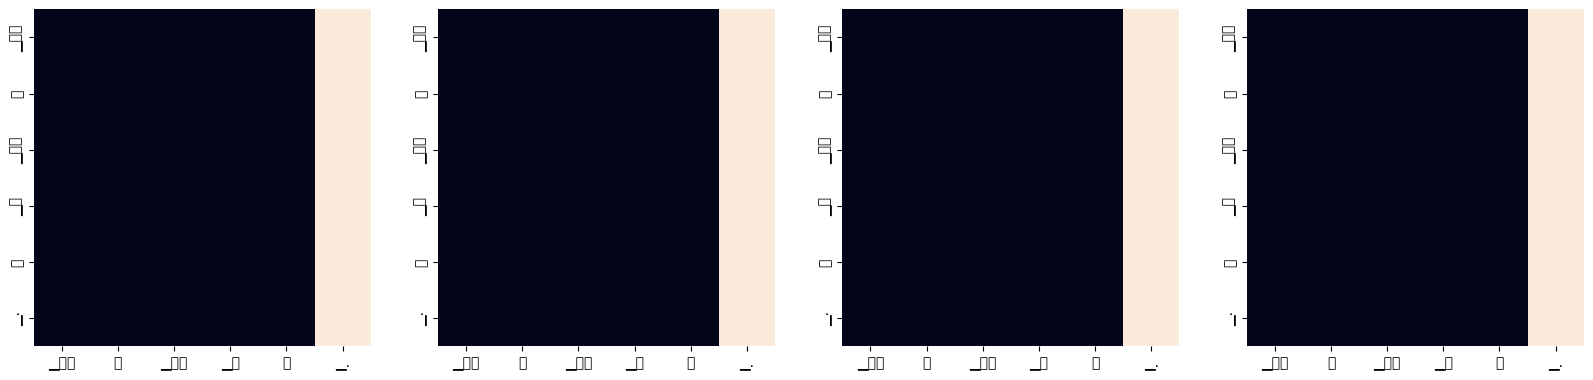

Encoder Layer 2


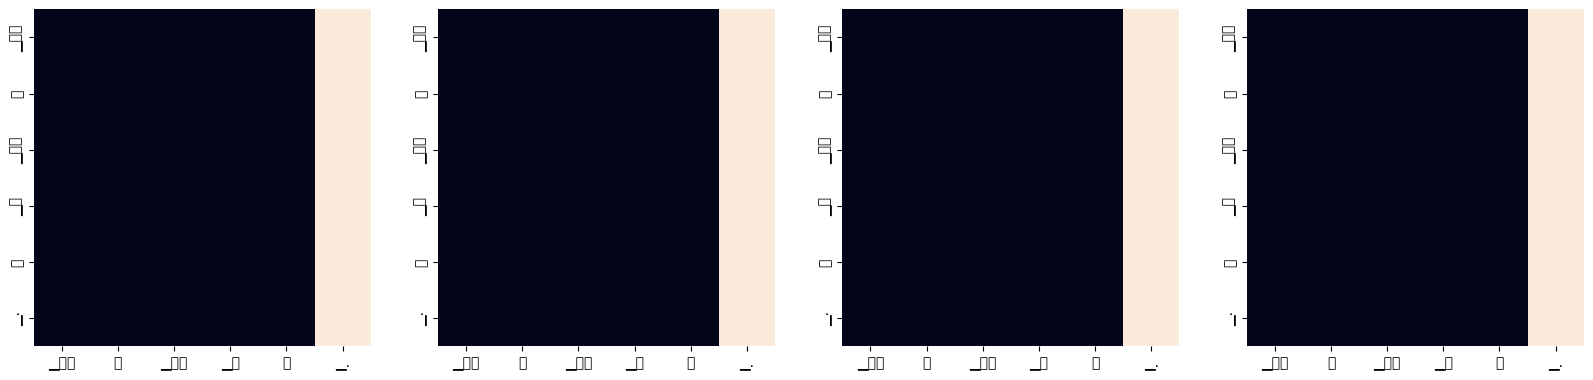

Decoder Self Layer 1


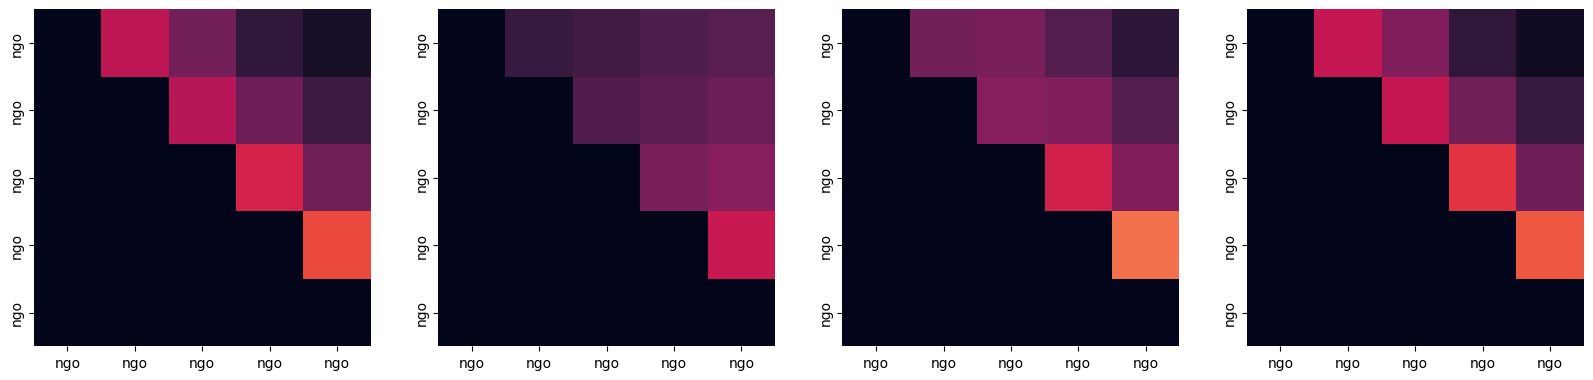

Decoder Src Layer 1


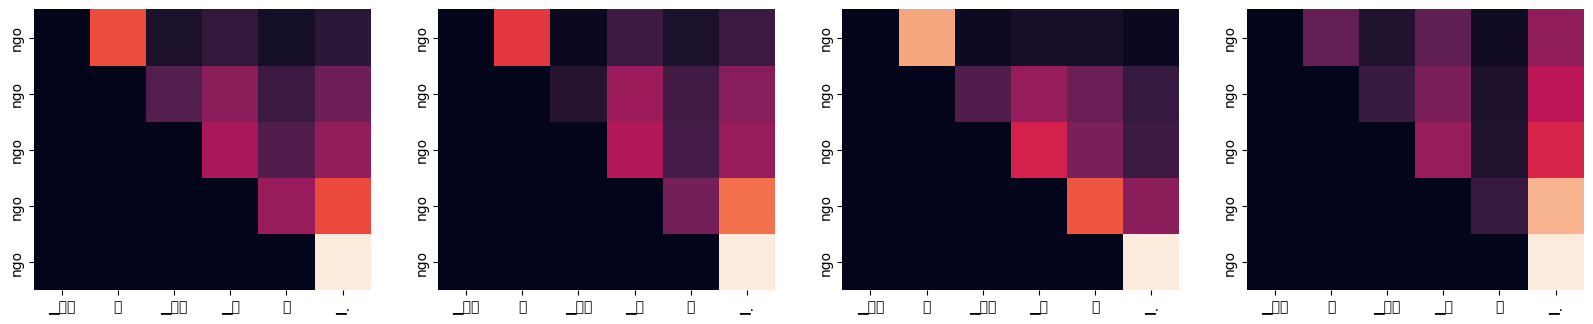

Decoder Self Layer 2


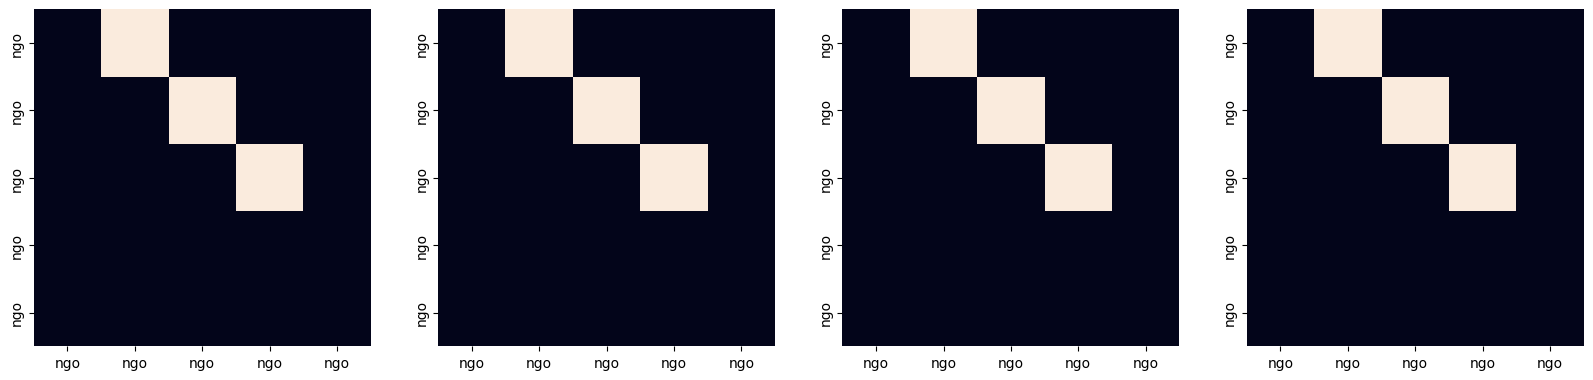

Decoder Src Layer 2


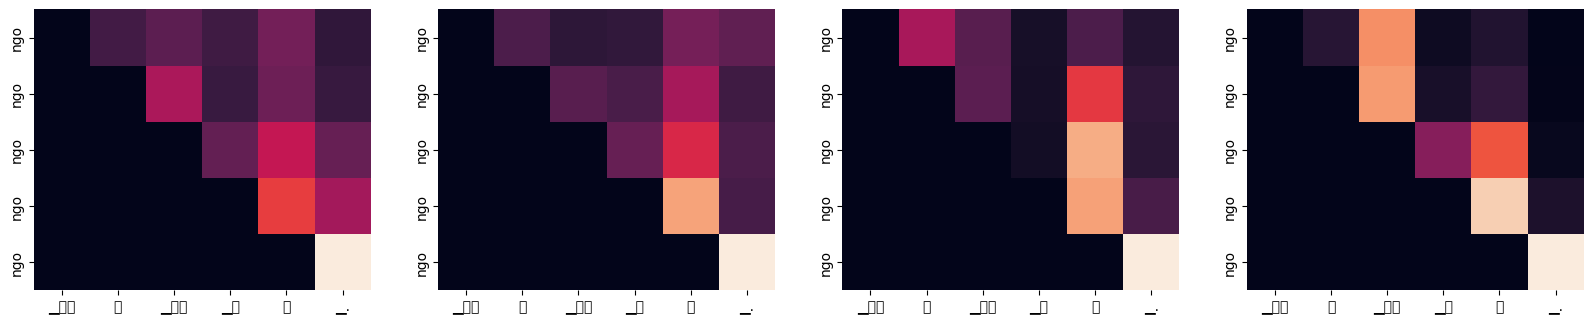


입력 문장: 일곱 명의 사망자가 발생했다.
(같은 토큰 반복 감지, 종료)
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ngo ngo ngo ngo ngo
Encoder Layer 1


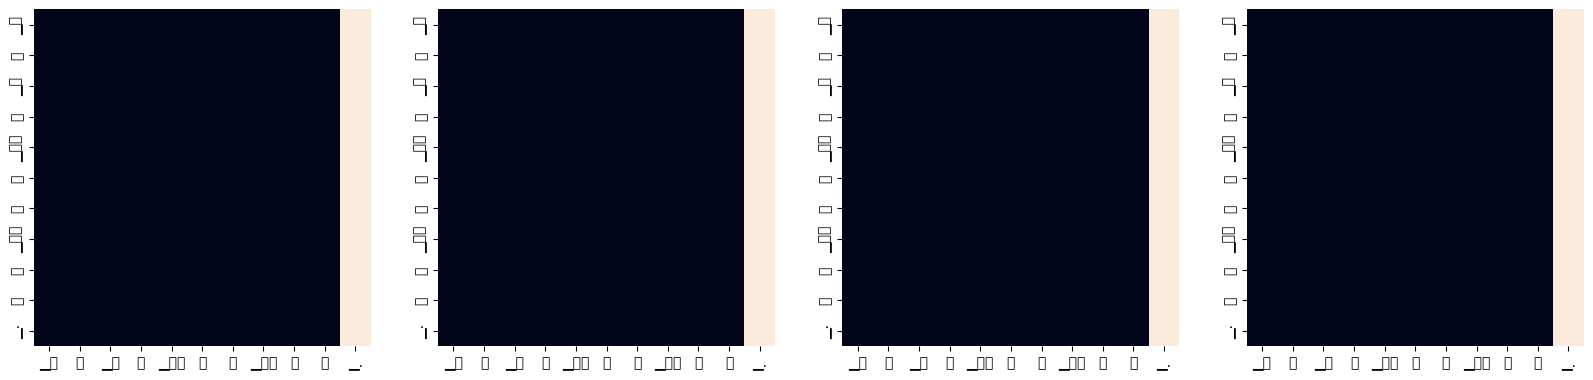

Encoder Layer 2


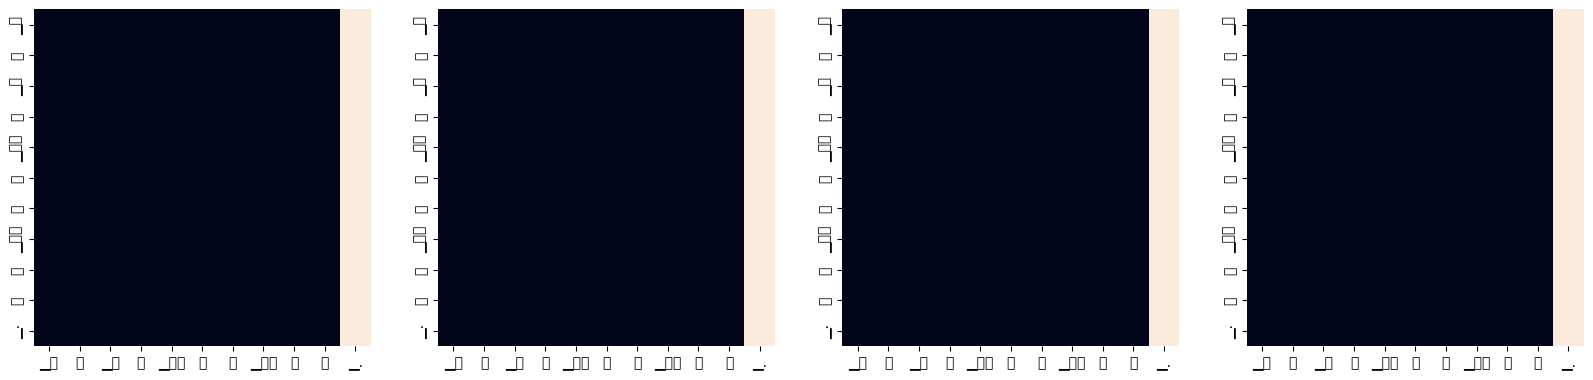

Decoder Self Layer 1


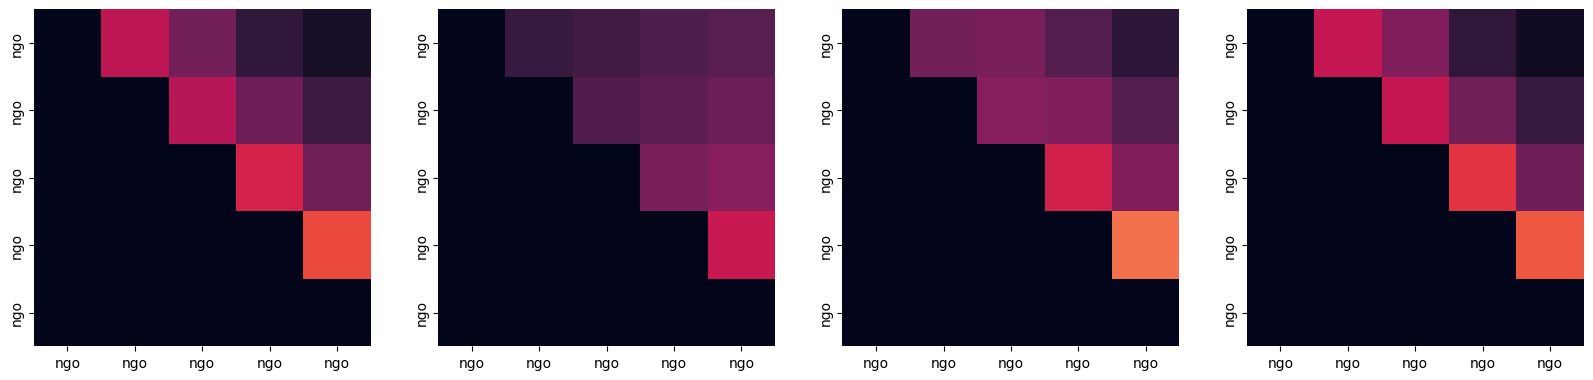

Decoder Src Layer 1


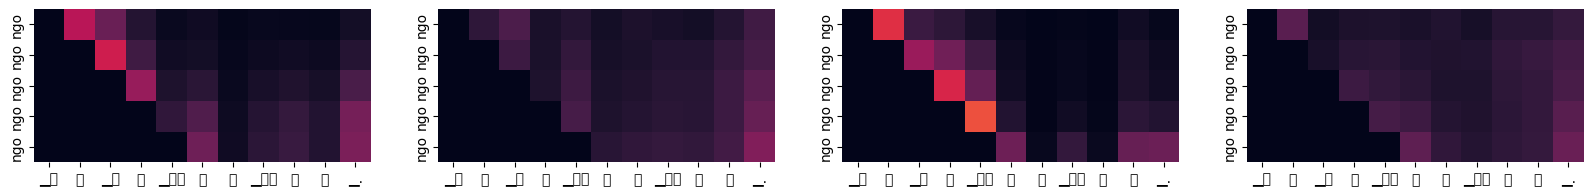

Decoder Self Layer 2


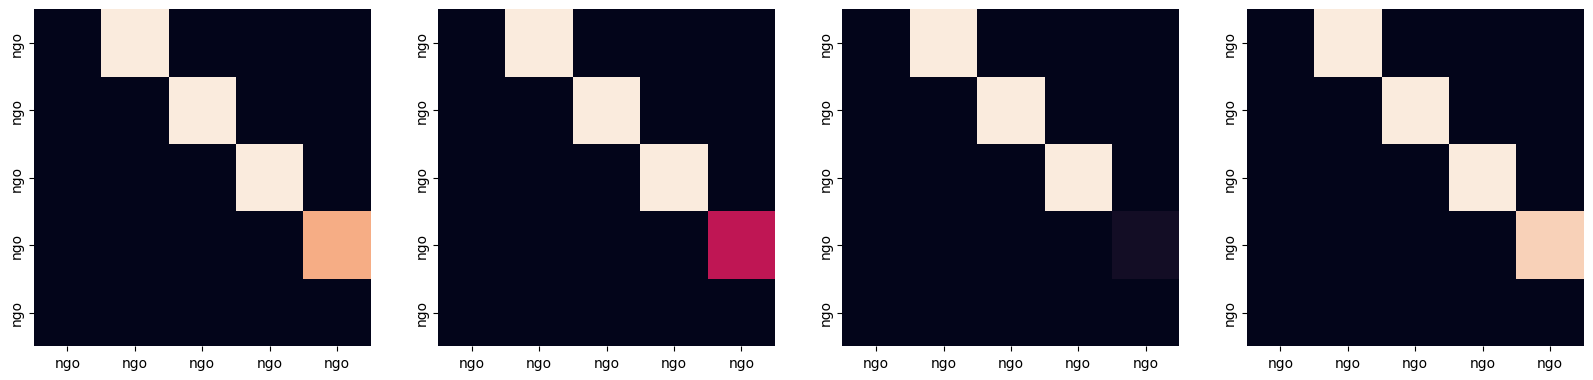

Decoder Src Layer 2


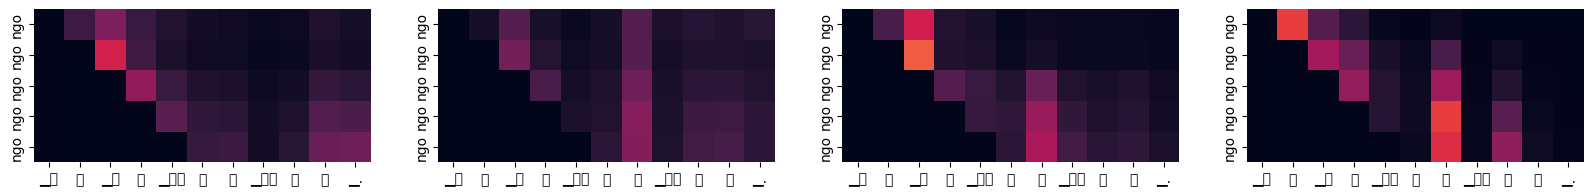

In [87]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

test_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.'
]

for sent in test_sentences:
    print(f'입력 문장: {sent}')
    translate(sent, transformer, ko_tokenizer, en_tokenizer, plot_attention=True)
    print()

# 퍼실님의 버그 해결
## 버그 수정

정답 파일 분석 결과 두 가지 치명적 버그 발견. 맨 아래에 수정 코드 추가함.

## 버그 1. masked_fill(mask == 0, -1e9) — 마스크 반전

패딩 마스크는 PAD 위치가 1, 유효 토큰이 0인데  
masked_fill(mask == 0, -1e9) 로 쓰면 유효 토큰(0)을 전부 -inf 처리해버림.  
결과적으로 PAD 토큰한테만 attention이 가는 완전히 뒤집힌 동작.

### 버그 2. cross-attention에 causal mask 투입

generate_masks()에서 dec_enc_causality_mask를 만들어서 cross-attention에 넘김.  
번역은 어순이 바뀌기 때문에 디코더는 인코더 출력 전체를 자유롭게 봐야 함.  
cross-attention에 causal mask 넣으면 앞쪽 인코더 토큰을 못 보게 되고,  
버그 1(마스크 반전)까지 겹치면 마지막 토큰은 attend할 게 없어서 NaN 발생.

#### 을 이 파일 뒤에다가 실행 해보려 했지만, 워낙 정의해놓은게 많고 변수 지정해놓은게 많아서...아무리 낑낑대도 새로 터져나오는 에러들을 잡기가 지쳐서 새로운 파일로 따로 만듬.